# Individuele opdracht Data Science — CRISP-DM
## Treinverstoringen voorspellen

> Deze opdracht is met behulp van een Large Language Model (LLM) aangepast, zodat de inhoud en het niveau optimaal aansluiten bij de verwachte kennis en vaardigheden van een tweedejaars ICT-student (BIM).

**Naam student:** Cesur Arslan  
**Studentnummer:** 1886728  

In deze individuele opdracht doorloop je de fasen van **CRISP-DM**. Je onderzoekt Nederlandse treinverstoringen en bouwt een model dat bij de start van een verstoring voorspelt of deze langer dan 60 minuten zal duren.

De nadruk ligt op het begrijpen van de data, aantoonbare datamanipulatie, een eerlijke modelvergelijking en een onderbouwde evaluatie. De fase **Deployment** valt buiten deze opdracht.

> Dit notebook volgt de eisen uit `Opdracht_CRISP-DM_treinverstoringen.docx`. Startcode laat een techniek en de reden erachter zien. Je moet de controles uitbreiden, keuzes onderbouwen en uitkomsten zelf interpreteren. Alleen de voorbeeldcode uitvoeren is niet voldoende.


## Overzicht en weging

| CRISP-DM-fase | Wat je aantoont | Weging |
|---|---|---:|
| 1. Business Understanding | Je begrijpt het doel van de voorspelling | 5% |
| 2. Data Understanding | Je begrijpt inhoud, typen, verdelingen en kwaliteit van de data | 20% |
| 3. Data Preparation | Je maakt de data met beargumenteerde manipulaties modelklaar | 30% |
| 4. Modeling | Je bouwt en vergelijkt een baseline en minimaal twee modellen | 20% |
| 5. Evaluation | Je test het gekozen model en vertaalt resultaten naar de businessvraag | 25% |

### Verplichte inleverproducten

Lever samen in:

1. dit volledig ingevulde en uitgevoerde notebook;
2. de voorbereide modeldataset vóór one-hot encoding als CSV;
3. een korte `README.md` of `README.txt` met startinstructie, Python-versie, packages en bestandsnamen.

Een HTML- of PDF-export mag als extra leesversie worden toegevoegd, maar vervangt het notebook niet. Het notebook moet van boven naar beneden opnieuw uitvoerbaar zijn. Gebruik overal `random_state=42` waar dat van toepassing is.


## Werkwijze en beoordelingsafspraken

- Schrijf bij iedere analyse op **wat je ziet**, **waarom dat belangrijk is** en **welke keuze daaruit volgt**.
- Leg beslissingen vast vóórdat je verdergaat. Voorbeelden zijn verwijderen, imputeren, categorieën samenvoegen en omgaan met uitschieters.
- Voorkom **data leakage**. Informatie die pas tijdens of na afloop van een verstoring beschikbaar is, mag niet als invoer van het model worden gebruikt.
- Laat datavoorbereiding die van waarden of frequenties leert uitsluitend op de trainingsdata plaatsvinden. Gebruik hiervoor bij voorkeur een scikit-learn `Pipeline` en `ColumnTransformer`.
- Vermeld geraadpleegde bronnen en eventuele AI-ondersteuning volgens de afspraken van de opleiding.

### Betekenis van labels

- `OPDRACHT`: dit moet je aantoonbaar opleveren.
- `TODO`: dit moet je aanvullen, activeren of aanpassen.
- `CONTROLEPUNT`: hiermee controleer je of je voldoende bewijs hebt geleverd.
- `VOORBEELD`: startcode die één techniek demonstreert. Controleer of de aanpak past bij jouw bevindingen.

Commentaar in de voorbeeldcode legt uit waarom een stap wordt uitgevoerd. Verwijder relevante uitleg niet zonder reden. Voeg eigen commentaar toe wanneer je een andere keuze maakt.


# 0. Voorbereiding

Plaats de dataset in dezelfde map als het notebook. De verwachte bestandsnaam is `Dataset.csv`. Het template herkent ook `Dataset(1).csv`, omdat een browser soms automatisch `(1)` toevoegt. De velden zijn met een puntkomma (`;`) gescheiden.

Voer eerst de importcel uit. De controle op 14 kolommen voorkomt dat een verkeerd scheidingsteken ongemerkt één brede tekstkolom oplevert. Voeg alleen bibliotheken toe die je daadwerkelijk gebruikt.


In [28]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", palette="colorblind")

# Relatieve paden blijven werken wanneer iemand de map verplaatst.
# De varianten met (1) vangen automatisch hernoemde downloads op.
candidate_paths = [
    Path("Dataset.csv"),
    Path("Dataset(1).csv"),
    Path("upload") / "Dataset.csv",
    Path("upload") / "Dataset(1).csv",
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    df_raw = None
    print("Dataset.csv is niet gevonden. Plaats het bestand naast het notebook en voer deze cel opnieuw uit.")
else:
    # sep=';' is nodig omdat komma's ook binnen meervoudige tekstvelden voorkomen.
    df_raw = pd.read_csv(DATA_PATH, sep=";")
    print(f"Data ingelezen uit: {DATA_PATH}")
    print(f"Omvang: {df_raw.shape[0]} rijen en {df_raw.shape[1]} kolommen")
    assert df_raw.shape[1] == 14, "Controleer het scheidingsteken; er worden 14 kolommen verwacht."


Data ingelezen uit: Dataset.csv
Omvang: 6676 rijen en 14 kolommen


# 1. Business Understanding — 5%

## Businessvraag

> **Kan op het moment dat een treinverstoring begint worden voorspeld of deze langer dan 60 minuten zal duren, op basis van de oorzaak, het getroffen traject, het aantal getroffen stations en het startmoment?**

Het gaat om een classificatieprobleem met twee klassen:

- `0`: de verstoring duurt maximaal 60 minuten;
- `1`: de verstoring duurt langer dan 60 minuten.

## Opdracht 1.1 — Korte duiding

Neem de businessvraag letterlijk over en licht in twee tot vier zinnen toe wie de voorspelling kan gebruiken en welke beslissing ermee wordt ondersteund. Benoem ook welk type fout volgens jou het zwaarst weegt. Deze keuze gebruik je later om de primaire evaluatiemaat te kiezen.

**Jouw antwoord:**

Deze voorspelling kan gebruikt worden door de medewerkers die bezig zijn met treinverstoringen en reizigersinformatie. Als zij al aan het begin een idee hebben of een verstoring lang gaat duren, kunnen zij sneller actie ondernemen e reizigers beter informeren. Ook kunnen zij eerder rekening houden met mogelijke vertragingenen problemen op het spoor. De fout die volgens mij het zwaarst weegt, is wanneer het model voorspelt dat een verstoring kort duurt, terwijl deze in werkelijkheid langer dan 60 minuten duurt. In dat geval kan er te laat worden gereageerd en worden reizigers mogelijk pas later goed geinformeerd. 

### Controlepunt

De zakelijke betekenis en het voorspelmoment zijn duidelijk. Een uitgebreide organisatieanalyse is niet nodig; de nadruk ligt op de volgende fasen.


# 2. Data Understanding — 20%

In deze fase leg je de oorspronkelijke toestand van de data vast. Reinig nog niets. Baseer je analyse ook op **Beschrijving van de data.docx**.

## Opdracht 2.1 — Inlezen en eerste controle

Onderzoek minimaal:

1. het gebruikte scheidingsteken en of alle 14 kolommen afzonderlijk zijn ingelezen;
2. het aantal rijen, kolommen en unieke verstorings-ID's;
3. de eerste vijf, laatste vijf en minimaal vijf willekeurige records;
4. de kolomnamen en door pandas herkende datatypen;
5. de vroegste en laatste bruikbare startdatum;
6. of `rdt_id` daadwerkelijk een unieke sleutel lijkt te zijn.

Gebruik de startcode en voeg eigen controles toe. Een tabel zonder interpretatie is niet voldoende.


In [29]:
if df_raw is not None:
    print("Vorm:", df_raw.shape)
    display(df_raw.head())
    display(df_raw.tail())

    # random_state maakt dezelfde steekproef opnieuw reproduceerbaar.
    display(df_raw.sample(5, random_state=RANDOM_STATE))
    display(df_raw.dtypes.rename("pandas_dtype").to_frame())

    # errors='coerce' maakt ongeldige teksten NaT. Zo kun je mislukte
    # conversies tellen zonder de ruwe kolom te overschrijven.
    start_time_check = pd.to_datetime(
        df_raw["start_time"], errors="coerce", dayfirst=True
    )
    print("Vroegste bruikbare start:", start_time_check.min())
    print("Laatste bruikbare start:", start_time_check.max())
    print("Lege starttijden:", start_time_check.isna().sum())
    print("Aantal unieke rdt_id's:", df_raw["rdt_id"].nunique(dropna=False))
    print("Aantal dubbele rdt_id's:", df_raw["rdt_id"].duplicated().sum())

    # TODO: controleer of de uitkomsten passen bij de informatie in de opdracht.


Vorm: (6676, 14)


,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
0,57284,Den Haag - Rotterdam - Dordrecht,Den Haag HS - Rotterdam Centraal,11,"Delft,Delft Campus,Schiedam Centrum","DT, DTCP, SDM",aanrijding,collision,aanrijding,collision,accidents,1-1-2025 04:16,1-1-2025 04:26,10.0
1,57285,Leiden - Rotterdam,Den Haag HS - Rotterdam Centraal,11,"Delft,Delft Campus,Schiedam Centrum","DT, DTCP, SDM",aanrijding,collision,aanrijding,collision,accidents,1-1-2025 04:27,1-1-2025 06:23,117.0
2,57286,Rotterdam - Dordrecht,Dordrecht - Rotterdam Centraal,16,"Barendrecht,Dordrecht,Rotterdam Lombardijen,Ro...","BRD, DDR, RLB, RTB, RTD, RTST, RTZ, ZWD",aanrijding,collision,aanrijding,collision,accidents,1-1-2025 04:27,1-1-2025 04:29,3.0
3,57287,Schiphol - Rotterdam,Rotterdam Centraal - Schiphol Airport (HSL),24,"Rotterdam Centraal,Schiphol Airport","RTD, SHL",verstoring elders,disruption elsewhere,verstoring elders,disruption elsewhere,logistical,1-1-2025 04:27,1-1-2025 04:27,0.0
4,57288,Schiphol - Rotterdam,Rotterdam Centraal - Schiphol Airport (HSL),24,"Rotterdam Centraal,Schiphol Airport","RTD, SHL",verstoring elders,disruption elsewhere,verstoring elders,disruption elsewhere,logistical,1-1-2025 04:27,1-1-2025 06:40,133.0


,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
6671,63955,Almelo - Hardenberg,Almelo - Mariënberg,96,"Almelo,Daarlerveen,Mariënberg,Vroomshoop,Vriez...","AML, DA, MRB, VHP, VZ",vandalisme,vandalism,vandalisme,vandalism,external,31-12-2025 15:14,31-12-2025 15:48,34.0
6672,63956,Schiphol Airport,"Amersfoort - Schiphol Airport, Amsterdam Centr...","22,24,32,137,144,148,165","Rosmalen,Schiphol Airport","RS, SHL",brandmelding,fire alarm,brandmelding,fire alarm,external,31-12-2025 16:19,31-12-2025 17:00,41.0
6673,63957,Almelo - Hardenberg,Almelo - Mariënberg,96,"Almelo,Daarlerveen,Mariënberg,Vroomshoop,Vriez...","AML, DA, MRB, VHP, VZ",vandalisme,vandalism,vandalisme,vandalism,external,31-12-2025 16:31,31-12-2025 21:15,284.0
6674,63958,Hilversum - Amersfoort Schothorst,Amersfoort - Zwolle,48,"Amersfoort Centraal,Amersfoort Schothorst","AMF, AMFS",defecte trein,broken down train,defecte trein,broken down train,rolling stock,31-12-2025 18:48,31-12-2025 19:40,51.0
6675,63959,Alkmaar,"Alkmaar - Amsterdam Centraal, Alkmaar - Den He...","161,162,163","Alkmaar,Oisterwijk,Dülken","AMR, OT, KDUL",aanrijding,collision,aanrijding,collision,accidents,31-12-2025 19:41,31-12-2025 19:46,6.0


,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
1575,58859,Utrecht - Nijmegen,Arnhem Centraal - Utrecht Centraal,133,"Arnhem Centraal,Ede-Wageningen,Oosterbeek,Wolf...","AH, ED, OTB, WF",inzet van hulpdiensten,an emergency call,inzet van hulpdiensten,an emergency call,external,18-3-2025 17:13,18-3-2025 17:23,10.0
6445,63729,'s-Hertogenbosch - Tilburg,'s-Hertogenbosch - Tilburg,69,"'s-Hertogenbosch,Tilburg","HT, TB",gestrande trein,stranded train,gestrande trein,stranded train,rolling stock,16-12-2025 07:50,16-12-2025 08:31,41.0
4622,61906,Hengelo - Bielefeld,Bielefeld Hbf - Hengelo,174,"Osnabrück Hbf,Bielefeld Hbf,Bünde (Westf)","OSNH, BIELEF, BUENDE",problemen op het spoor in het buitenland,railway problems abroad,problemen op het spoor in het buitenland,railway problems abroad,logistical,9-9-2025 09:33,9-9-2025 21:45,733.0
2107,59391,Almelo - Hardenberg,Almelo - Mariënberg,96,"Almelo,Daarlerveen,Hardenberg,Mariënberg,Vroom...","AML, DA, HDB, MRB, VHP, VZ",beperkingen in de materieelinzet,problems with the rolling stock,beperkingen in de materieelinzet,problems with the rolling stock,rolling stock,17-4-2025 06:24,17-4-2025 09:01,157.0
1360,58644,Hilversum - Amersfoort Schothorst,Amersfoort - Zwolle,48,"Amersfoort Centraal,Amersfoort Schothorst","AMF, AMFS",wisselstoring,points failure,wisselstoring,points failure,infrastructure,6-3-2025 19:11,6-3-2025 22:18,186.0


,pandas_dtype
rdt_id,int64
ns_lines,str
rdt_lines,str
rdt_lines_id,str
rdt_station_names,str
rdt_station_codes,str
cause_nl,str
cause_en,str
statistical_cause_nl,str
statistical_cause_en,str


Vroegste bruikbare start: 2025-01-01 04:16:00
Laatste bruikbare start: 2025-12-31 19:41:00
Lege starttijden: 939
Aantal unieke rdt_id's: 6676
Aantal dubbele rdt_id's: 0


### Bevindingen eerste inspectie

Beschrijf hier drie tot vijf relevante bevindingen. Vermeld niet alleen aantallen, maar leg uit wat ze betekenen voor de rest van je analyse.

**Jouw bevindingen:**

1: De dataset is goed ingelezen met een (;) als scheidingsteken. De dataset bevat 6676 rijen en 14 kolommen, wat overeenkomt met de informatie uit de opdracht 
2: De kolom rdt_id bevat 6676 unieke waarden en er zijn geen dubbele ID's gevonden. Dit betekent dat iedere treinverstoringen een eigen uniek nummer heeft. Dat past bij de beschrijvingen van rdt_id als uniek ID van een verstoring 
3: De vroegste bruikbare startdatum is 1 januari 2025 om 4:16 en de laatsate is 31 december 2025 om 19:41 de dataset bevat dus verstoringen uit het hele jaar 2025, zoals ook in de opdracht dstaat vermeld. 
4: Bij start_time ontbreken 939 waarden. De starttijd is belangrijk voor het maken van kenmerken zoals het uur, de maand en de weekdag. Daarom moet ik later onderzoeken hoe ik met deze ontbrekende waarden omga. De data wordt in deze fase nog niet opgeschoond.

## Opdracht 2.2 — Datatypen, meetniveaus en rollen

Maak voor **alle 14 variabelen** een datawoordenboek met minimaal:

- betekenis van het veld;
- huidig technisch datatype;
- gewenst datatype;
- meetniveau: nominaal, ordinaal, interval of ratio;
- inhoudelijke vorm, zoals identifier, datum/tijd, categorie of multi-value tekstveld;
- mogelijke rol: invoerkenmerk, doelbron, controleveld of niet gebruiken;
- korte toelichting.

Een numerieke code is niet automatisch een kwantitatieve variabele. `rdt_id` is bijvoorbeeld numeriek opgeslagen, maar heeft inhoudelijk de rol van nominale identifier.


In [30]:
if df_raw is not None:
    data_dictionary = pd.DataFrame(index=df_raw.columns).reset_index(names="kolom")
    data_dictionary["huidig_dtype"] = [str(dtype) for dtype in df_raw.dtypes]

    info = {
        "rdt_id": [
            "Uniek nummer van een verstoring",
            "Int64",
            "nominaal",
            "identifier",
            "controleveld",
            "Wordt gebruikt om elke verstoring te herkennen"
        ],
        "ns_lines": [
            "Getroffen trajecten volgens NS",
            "string",
            "nominaal",
            "multi-value tekstveld",
            "niet gebruiken",
            "De trajectnamen zijn niet gestandaardiseerd"
        ],
        "rdt_lines": [
            "Getroffen trajecten volgens Rijden de Treinen",
            "string",
            "nominaal",
            "multi-value tekstveld",
            "invoerkenmerk",
            "Deze trajecten zijn beter geschikt voor analyse"
        ],
        "rdt_lines_id": [
            "ID's van de getroffen trajecten",
            "string",
            "nominaal",
            "multi-value identifier",
            "invoerkenmerk",
            "Kan gebruikt worden om het aantal getroffen trajecten te bepalen"
        ],
        "rdt_station_names": [
            "Namen van de getroffen stations",
            "string",
            "nominaal",
            "multi-value tekstveld",
            "invoerkenmerk",
            "Kan gebruikt worden om het aantal getroffen stations te bepalen"
        ],
        "rdt_station_codes": [
            "Codes van de getroffen stations",
            "string",
            "nominaal",
            "multi-value identifier",
            "controleveld",
            "Kan gebruikt worden om de stationsnamen te controleren"
        ],
        "cause_nl": [
            "Oorzaak van de verstoring in het Nederlands",
            "string",
            "nominaal",
            "categorie",
            "invoerkenmerk",
            "De oorzaak kan invloed hebben op de duur van de verstoring"
        ],
        "cause_en": [
            "Oorzaak van de verstoring in het Engels",
            "string",
            "nominaal",
            "categorie",
            "niet gebruiken",
            "Bevat dezelfde informatie als cause_nl maar dan in het Engels"
        ],
        "statistical_cause_nl": [
            "Statistische oorzaak van de verstoring",
            "string",
            "nominaal",
            "categorie",
            "invoerkenmerk",
            "Kan gebruikt worden om verstoringen per oorzaak te vergelijken"
        ],
        "statistical_cause_en": [
            "Statistische oorzaak in het Engels",
            "string",
            "nominaal",
            "categorie",
            "niet gebruiken",
            "Is de Engelse versie van statistical_cause_nl"
        ],
        "cause_group": [
            "Groep van de oorzaak",
            "string",
            "nominaal",
            "categorie",
            "invoerkenmerk",
            "Geeft aan bij welke soort oorzaak de verstoring hoort"
        ],
        "start_time": [
            "Tijd waarop de verstoring begon",
            "datetime64[ns]",
            "interval",
            "datum/tijd",
            "invoerkenmerk",
            "Hieruit kunnen bijvoorbeeld uur, maand en weekdag worden gehaald"
        ],
        "end_time": [
            "Tijd waarop de verstoring eindigde",
            "datetime64[ns]",
            "interval",
            "datum/tijd",
            "doelbron",
            "Deze informatie is bij de start nog niet bekend"
        ],
        "duration_minutes": [
            "Duur van de verstoring in minuten",
            "Float64",
            "ratio",
            "numerieke waarde",
            "doelbron",
            "Wordt gebruikt om te bepalen of een verstoring langer dan 60 minuten duurt"
        ]
    }

    data_dictionary["betekenis"] = data_dictionary["kolom"].map(lambda x: info[x][0])
    data_dictionary["gewenst_dtype"] = data_dictionary["kolom"].map(lambda x: info[x][1])
    data_dictionary["meetniveau"] = data_dictionary["kolom"].map(lambda x: info[x][2])
    data_dictionary["inhoudelijke_vorm"] = data_dictionary["kolom"].map(lambda x: info[x][3])
    data_dictionary["mogelijke_rol"] = data_dictionary["kolom"].map(lambda x: info[x][4])
    data_dictionary["toelichting"] = data_dictionary["kolom"].map(lambda x: info[x][5])

    display(data_dictionary)

,kolom,huidig_dtype,betekenis,gewenst_dtype,meetniveau,inhoudelijke_vorm,mogelijke_rol,toelichting
0,rdt_id,int64,Uniek nummer van een verstoring,Int64,nominaal,identifier,controleveld,Wordt gebruikt om elke verstoring te herkennen
1,ns_lines,str,Getroffen trajecten volgens NS,string,nominaal,multi-value tekstveld,niet gebruiken,De trajectnamen zijn niet gestandaardiseerd
2,rdt_lines,str,Getroffen trajecten volgens Rijden de Treinen,string,nominaal,multi-value tekstveld,invoerkenmerk,Deze trajecten zijn beter geschikt voor analyse
3,rdt_lines_id,str,ID's van de getroffen trajecten,string,nominaal,multi-value identifier,invoerkenmerk,Kan gebruikt worden om het aantal getroffen tr...
4,rdt_station_names,str,Namen van de getroffen stations,string,nominaal,multi-value tekstveld,invoerkenmerk,Kan gebruikt worden om het aantal getroffen st...
5,rdt_station_codes,str,Codes van de getroffen stations,string,nominaal,multi-value identifier,controleveld,Kan gebruikt worden om de stationsnamen te con...
6,cause_nl,str,Oorzaak van de verstoring in het Nederlands,string,nominaal,categorie,invoerkenmerk,De oorzaak kan invloed hebben op de duur van d...
7,cause_en,str,Oorzaak van de verstoring in het Engels,string,nominaal,categorie,niet gebruiken,Bevat dezelfde informatie als cause_nl maar da...
8,statistical_cause_nl,str,Statistische oorzaak van de verstoring,string,nominaal,categorie,invoerkenmerk,Kan gebruikt worden om verstoringen per oorzaa...
9,statistical_cause_en,str,Statistische oorzaak in het Engels,string,nominaal,categorie,niet gebruiken,Is de Engelse versie van statistical_cause_nl


## Opdracht 2.3 — Datakwaliteit

Onderzoek en bespreek minimaal:

1. ontbrekende waarden per kolom, in aantal én percentage;
2. patronen van gelijktijdig ontbrekende velden;
3. volledig dubbele rijen en dubbele identifiers;
4. ongeldige datums en eindtijden vóór starttijden;
5. negatieve, nul- en uitzonderlijk hoge duren;
6. overeenstemming tussen `duration_minutes` en het verschil tussen start- en eindtijd;
7. overeenstemming tussen aantallen stationsnamen en stationcodes;
8. overeenstemming tussen aantallen trajectnamen en traject-ID's;
9. hoofdletters, witruimte, lege teksten en zeldzame categorieën in minimaal `cause_group`, `statistical_cause_nl` en `rdt_lines`;
10. velden die door het voorspelmoment of hun betekenis ongeschikt zijn als modelinvoer.

Maak bij ieder probleem duidelijk hoe je het hebt ontdekt, hoe groot het is, wat het kan betekenen en wat je er in Data Preparation mee gaat doen.


In [31]:
if df_raw is not None:
    missing_patterns = (
        df_raw.isna()
        .astype(int)
        .groupby(list(df_raw.columns))
        .size()
        .sort_values(ascending=False)
        .rename("aantal_rijen")
        .reset_index()
    )

    display(missing_patterns.head(10))

    # Bekijk de rijen waarin precies 2 velden ontbreken
    rows_with_two_missing = df_raw[df_raw.isna().sum(axis=1) == 2]
    display(rows_with_two_missing)

    # Bekijk de rijen waarin 12 velden tegelijk ontbreken
    rows_with_twelve_missing = df_raw[df_raw.isna().sum(axis=1) == 12]
    display(rows_with_twelve_missing.head())

    print("Rijen zonder ontbrekende waarden:", (df_raw.isna().sum(axis=1) == 0).sum())
    print("Rijen met 2 ontbrekende waarden:", (df_raw.isna().sum(axis=1) == 2).sum())
    print("Rijen met 12 ontbrekende waarden:", (df_raw.isna().sum(axis=1) == 12).sum())

# Uit de controle blijkt dat 5.735 rijen geen ontbrekende waarden hebben. Bij 939 rijen ontbreken 12 velden tegelijk. In deze rijen zijn bijna alleen `rdt_id` en `ns_lines` ingevuld. Deze rijen bevatten daardoor weinig bruikbare informatie voor het maken van een voorspelling.
# Daarnaast zijn er 2 rijen waarin precies 2 waarden ontbreken. Bij één rij ontbreken `end_time` en `duration_minutes`. Bij de andere rij ontbreken `rdt_lines` en `rdt_lines_id`. In Data Preparation ga ik bepalen hoe ik met deze ontbrekende gegevens omga.


,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes,aantal_rijen
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5735
1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,939
2,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1
3,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1


,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
2929,60213,'s-Hertogenbosch - Tilburg,'s-Hertogenbosch - Tilburg,69,"'s-Hertogenbosch,Tilburg","HT, TB",aanrijding,collision,aanrijding,collision,accidents,4-6-2025 19:14,NaN,NaN
4012,61296,Lelystad Centrum - Rotterdam - Brussel,NaN,NaN,"Abcoude,Almere Centrum,Almere Buiten,Almere Mu...","AC, ALM, ALMB, ALMM, ALMO, ALMP, ASB, ASHD, BK...",aangepaste dienstregeling,an amended timetable,aangepaste dienstregeling,an amended timetable,weather,4-8-2025 08:12,4-8-2025 22:02,830.0


,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
5,57289,Dordrecht - Breda,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,57295,Hilversum - Amersfoort,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,57300,Breda - Eindhoven,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,57311,Sittard - Heerlen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,57314,Zwolle - Groningen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Rijen zonder ontbrekende waarden: 5735
Rijen met 2 ontbrekende waarden: 2
Rijen met 12 ontbrekende waarden: 939


In [32]:
if df_raw is not None:
    start_check = pd.to_datetime(df_raw["start_time"], errors="coerce", dayfirst=True)
    end_check = pd.to_datetime(df_raw["end_time"], errors="coerce", dayfirst=True)
    calc_check = (end_check - start_check).dt.total_seconds()/60
    time_quality = pd.Series({
        "start_time niet parsebaar": start_check.isna().sum(),
        "end_time niet parsebaar": end_check.isna().sum(),
        "eindtijd vóór starttijd": ((end_check < start_check) & start_check.notna() & end_check.notna()).sum(),
        "duration ontbreekt": df_raw["duration_minutes"].isna().sum(),
        "duration < 0": (df_raw["duration_minutes"] < 0).sum(),
        "duration == 0": (df_raw["duration_minutes"] == 0).sum(),
        "duurverschil > 5 minuten": ((df_raw["duration_minutes"]-calc_check).abs() > 5).sum(),
        "duurverschil exact 0": ((df_raw["duration_minutes"]-calc_check).abs() < 1e-9).sum()
    })
    display(time_quality.to_frame("aantal"))
 
    discrepancy = df_raw.loc[
        df_raw["duration_minutes"].notna() & calc_check.notna() &
        ((df_raw["duration_minutes"]-calc_check).abs() > 5),
        ["rdt_id","start_time","end_time","duration_minutes"]
    ].copy()
    discrepancy["calculated_duration_minutes"] = calc_check.loc[discrepancy.index]
    display(discrepancy)

,aantal
start_time niet parsebaar,939
end_time niet parsebaar,940
eindtijd vóór starttijd,0
duration ontbreekt,940
duration < 0,0
duration == 0,63
duurverschil > 5 minuten,1
duurverschil exact 0,4367


,rdt_id,start_time,end_time,duration_minutes,calculated_duration_minutes
5483,62767,25-10-2025 00:47,27-10-2025 23:52,4325.0,4265.0


In [33]:
def count_multivalue_items(value, separator=","):
    '''Tel niet-lege, door een scheidingsteken gescheiden onderdelen.'''
    if pd.isna(value):
        return np.nan
    items = [item.strip() for item in str(value).split(separator)]
    return sum(bool(item) for item in items)


if df_raw is not None:
    station_name_count = df_raw["rdt_station_names"].map(count_multivalue_items)
    station_code_count = df_raw["rdt_station_codes"].map(count_multivalue_items)
    line_name_count = df_raw["rdt_lines"].map(count_multivalue_items)
    line_id_count = df_raw["rdt_lines_id"].map(count_multivalue_items)

    # Vergelijk alleen rijen waarin beide waarden aanwezig zijn. Zonder dit masker
    # kan NaN != NaN ten onrechte als een inhoudelijke afwijking worden geteld.
    comparable_stations = station_name_count.notna() & station_code_count.notna()
    comparable_lines = line_name_count.notna() & line_id_count.notna()
    station_mismatch = comparable_stations & (station_name_count != station_code_count)
    line_mismatch = comparable_lines & (line_name_count != line_id_count)

    print("Vergelijkbare stationsrecords:", comparable_stations.sum())
    print("Afwijkend aantal stationsnamen en -codes:", station_mismatch.sum())
    print("Vergelijkbare trajectrecords:", comparable_lines.sum())
    print("Afwijkend aantal trajectnamen en -ID's:", line_mismatch.sum())

    display(df_raw.loc[station_mismatch, [
        "rdt_id", "rdt_station_names", "rdt_station_codes"
    ]].head(10))
    display(df_raw.loc[line_mismatch, [
        "rdt_id", "rdt_lines", "rdt_lines_id"
    ]].head(10))

# TODO: ### Bevindingen stations en trajecten

# Bij 5.737 records konden de stationsnamen en stationcodes met elkaar worden vergeleken. Er zijn geen verschillen gevonden tussen het aantal stationsnamen en het aantal stationcodes.

# Bij 5.736 records konden de trajectnamen en traject-ID's met elkaar worden vergeleken. Ook hier zijn geen verschillen gevonden.

# Dit betekent dat deze gegevens goed met elkaar overeenkomen. Voor het model gebruik ik later vooral `rdt_station_names` om het aantal getroffen stations te bepalen en `rdt_lines` om informatie over de getroffen trajecten te gebruiken. De ID-kolommen kan ik vooral gebruiken als controle.


Vergelijkbare stationsrecords: 5737
Afwijkend aantal stationsnamen en -codes: 0
Vergelijkbare trajectrecords: 5736
Afwijkend aantal trajectnamen en -ID's: 0


,rdt_id,rdt_station_names,rdt_station_codes


,rdt_id,rdt_lines,rdt_lines_id


### Categorische kwaliteit

Onderstaande startcode kwantificeert enkele veelvoorkomende problemen. Een categorie met weinig records is niet automatisch fout. Zeldzaamheid kan wel leiden tot instabiele dummyvariabelen of zeer kleine analysegroepen.


In [34]:
if df_raw is not None:
    category_quality = []
    for column in ["cause_group", "statistical_cause_nl", "rdt_lines"]:
        values = df_raw[column].dropna().astype(str)
        frequencies = values.value_counts()
        category_quality.append({
            "kolom": column,
            "unieke_waarden": values.nunique(),
            "categorieen_minder_dan_5": (frequencies < 5).sum(),
            "voor_of_achterspatie": (values != values.str.strip()).sum(),
            "lege_tekst": values.str.strip().eq("").sum(),
        })
    display(pd.DataFrame(category_quality))

# TODO: ### Bevindingen categorische kwaliteit

# Bij `cause_group` zijn 9 verschillende categorieën gevonden. Er zijn geen lege teksten, extra spaties of categorieën die minder dan 5 keer voorkomen.

# Bij `statistical_cause_nl` zijn 63 verschillende categorieën gevonden. Hiervan komen 18 categorieën minder dan 5 keer voor. Deze zeldzame categorieën kunnen later lastig zijn voor het model, omdat er weinig voorbeelden van zijn.

# Bij `rdt_lines` zijn 217 verschillende waarden gevonden. Hiervan komen 64 waarden minder dan 5 keer voor. Ook hier zijn geen lege teksten of extra spaties gevonden.

# In Data Preparation ga ik bekijken of sommige zeldzame categorieën samengevoegd kunnen worden. Ik voeg categorieën alleen samen als daar een duidelijke reden voor is.


,kolom,unieke_waarden,categorieen_minder_dan_5,voor_of_achterspatie,lege_tekst
0,cause_group,9,0,0,0
1,statistical_cause_nl,63,18,0,0
2,rdt_lines,217,64,0,0


### Datakwaliteitsrapport

Sluit Data Understanding af met minimaal vijf concreet gevonden problemen. Gebruik exacte aantallen uit je code.

| Kolom(men) | Probleem | Aantal / % | Mogelijk gevolg | Voorgenomen behandeling |
|---|---|---:|---|---|
| Meerdere kolommen | Veel gegevens ontbreken tegelijk | 939 rijen / 14,07% | Deze rijen bevatten bijna geen bruikbare informatie | In Data Preparation bekijken of deze rijen verwijderd moeten worden |
| rdt_lines, rdt_lines_id, end_time, duration_minutes | Ontbrekende waarden | 940 / 14,08% | Niet alle informatie is beschikbaar voor de analyse | Per kolom bepalen of verwijderen of een andere oplossing nodig is |
| duration_minutes | Duur is 0 minuten | 63 rijen / 0,94% | Dit kan een echte korte storing zijn, maar ook een fout in de data | Deze rijen verder controleren en niet direct verwijderen |
| duration_minutes | Zeer lange verstoringen van meer dan één dag | 66 rijen / 0,99% | Deze uitschieters kunnen invloed hebben op de analyse | Eerst onderzoeken of het echte verstoringen zijn |
| start_time, end_time, duration_minutes | Berekende duur komt niet overeen met geregistreerde duur | 1 rij / ongeveer 0,02% | De duur van deze verstoring kan verkeerd geregistreerd zijn | Deze rij controleren en bepalen welke duur het meest betrouwbaar is |
|statistical_cause_nl | Zeldzame categorieën | 18 categorieën komen minder dan 5 keer voor | Het model kan moeite hebben met categorieën waar weinig voorbeelden van zijn | Mogelijk zeldzame categorieën samenvoegen |
| rdt_lines | Zeldzame trajecten | 64 categorieën komen minder dan 5 keer voor | Er ontstaan veel kleine groepen in het model | Bekijken of trajecten anders verwerkt kunnen worden |
| end_time, duration_minutes | Deze gegevens zijn bij de start van de storing nog niet bekend | Niet van toepassing | Het model zou informatie uit de toekomst gebruiken | Niet gebruiken als invoerkenmerk |

## Opdracht 2.4 — Verkennende data-analyse

Beschrijf eerst passende centrum-, spreidings- en percentielmaten voor `duration_minutes`. Onderzoek daarnaast minimaal `cause_group`, `statistical_cause_nl` en `rdt_lines` met frequenties.

Maak minimaal **vier informatieve visualisaties**:

1. een verdelingsplot van `duration_minutes`;
2. een categorische vergelijking, bijvoorbeeld duur per `cause_group`;
3. een tijdsplot per maand, weekdag of startuur;
4. een visualisatie van ontbrekende waarden.

Een vijfde visualisatie die verband houdt met de toekomstige doelvariabele is aanbevolen. Gebruik in Data Understanding dan duidelijk het woord *voorlopig*, omdat de definitieve target pas na de kwaliteitskeuze in Data Preparation wordt gemaakt.

Iedere figuur bevat een titel, aslabels en een korte interpretatie. Meld en onderbouw iedere begrenzing of log-schaal.


,duration_minutes
count,5736.000000
mean,172.918759
std,729.712677
min,0.000000
1%,0.000000
5%,4.000000
25%,22.000000
50%,51.000000
75%,135.000000
95%,616.000000


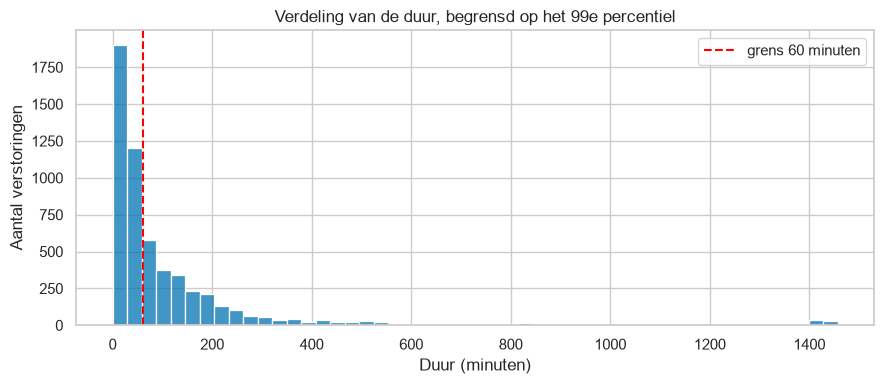

De figuur is begrensd op 1459.6 minuten.


In [35]:
# VOORBEELD 1: percentielen helpen een leesbare uitsnede te kiezen.
if df_raw is not None:
    display(df_raw["duration_minutes"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    ).to_frame())

    upper_99 = df_raw["duration_minutes"].quantile(0.99)
    readable_duration = df_raw[df_raw["duration_minutes"] <= upper_99]

    plt.figure(figsize=(9, 4))
    sns.histplot(data=readable_duration, x="duration_minutes", bins=50)
    plt.axvline(60, color="red", linestyle="--", label="grens 60 minuten")
    plt.title("Verdeling van de duur, begrensd op het 99e percentiel")
    plt.xlabel("Duur (minuten)")
    plt.ylabel("Aantal verstoringen")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"De figuur is begrensd op {upper_99:.1f} minuten.")

#Interpretatie verdeling van de duur
# De grafiek is begrensd op het 99e percentiel. Hierdoor zijn de langste 1% van de verstoringen niet zichtbaar in deze figuur. Deze waarden zijn niet verwijderd uit de dataset, maar alleen buiten beeld gelaten zodat de meeste verstoringen beter zichtbaar zijn.
# De verdeling is duidelijk scheef naar rechts. De meeste verstoringen duren relatief kort, maar er zijn ook een klein aantal verstoringen die veel langer duren. Hierdoor ligt het gemiddelde hoger dan de mediaan.
# De rode lijn bij 60 minuten laat de grens zien die later wordt gebruikt om de doelvariabele te maken. Verstoring boven deze grens worden later gezien als langdurige verstoringen.

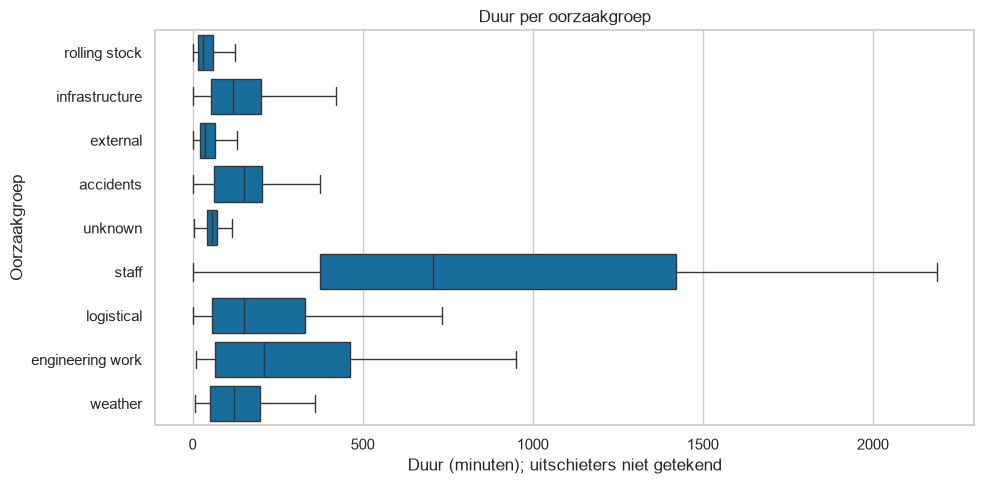


Top 10 voor cause_group


,aantal
cause_group,
rolling stock,2608
infrastructure,1316
NaN,939
external,728
accidents,360
unknown,236
staff,197
logistical,129
engineering work,116



Top 10 voor statistical_cause_nl


,aantal
statistical_cause_nl,
defecte trein,2118
NaN,939
seinstoring,448
gestrande trein,363
aanrijding,335
wisselstoring,305
technisch onderzoek,234
persoon op het spoor,181
inzet van hulpdiensten,145



Top 10 voor rdt_lines


,aantal
rdt_lines,
NaN,940
Breda - Rotterdam Centraal (HSL),253
Rotterdam Centraal - Schiphol Airport (HSL),150
Amersfoort - Zwolle,127
Leiden Centraal - Schiphol Airport,123
's-Hertogenbosch - Nijmegen,118
Eindhoven - Venlo,107
Aachen Hbf - Heerlen,106
Leiden Centraal - Utrecht Centraal,103


In [36]:
# VOORBEELD 2: vergelijk duur tussen oorzaakgroepen.
if df_raw is not None:
    cause_order = df_raw["cause_group"].value_counts().index
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=df_raw, x="duration_minutes", y="cause_group",
        order=cause_order, showfliers=False
    )
    plt.title("Duur per oorzaakgroep")
    plt.xlabel("Duur (minuten); uitschieters niet getekend")
    plt.ylabel("Oorzaakgroep")
    plt.tight_layout()
    plt.show()

    # De opdracht vraagt ook categorische frequenties voor deze drie velden.
    for column in ["cause_group", "statistical_cause_nl", "rdt_lines"]:
        print(f"\nTop 10 voor {column}")
        display(df_raw[column].value_counts(dropna=False).head(10).rename("aantal").to_frame())

# Interpretatie oorzaakgroepen
# De oorzaakgroepen verschillen duidelijk in hoe vaak ze voorkomen. Sommige groepen komen veel vaker voor dan andere. Dit betekent dat het model later meer voorbeelden heeft van veelvoorkomende oorzaakgroepen dan van zeldzame groepen.
# Ook de duur verschilt per oorzaakgroep. Bij sommige groepen ligt de mediaan hoger en duren verstoringen dus meestal langer. Bij andere groepen is de duur juist korter.
# In de boxplot zijn de uitschieters niet getekend. Dit is alleen gedaan om de verschillen tussen de oorzaakgroepen beter zichtbaar te maken. De uitschieters zijn niet uit de dataset verwijderd.
# Bij `cause_group`, `statistical_cause_nl` en `rdt_lines` zijn ook duidelijke verschillen in aantallen te zien. Vooral bij `statistical_cause_nl` en `rdt_lines` komen sommige waarden maar weinig voor. Dit kan later invloed hebben op het model, omdat zeldzame categorieën minder goed geleerd kunnen worden.

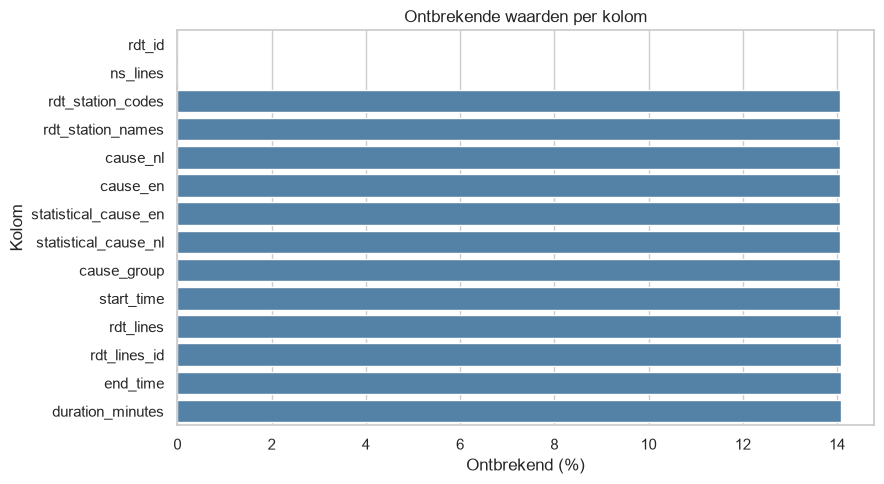

In [37]:
# VOORBEELD 3: visualiseer ontbrekende waarden per kolom.
if df_raw is not None:
    missing_for_plot = (
        df_raw.isna().mean().mul(100).sort_values().rename("percentage").reset_index()
    )
    plt.figure(figsize=(9, 5))
    sns.barplot(data=missing_for_plot, x="percentage", y="index", color="steelblue")
    plt.title("Ontbrekende waarden per kolom")
    plt.xlabel("Ontbrekend (%)")
    plt.ylabel("Kolom")
    plt.tight_layout()
    plt.show()

# ### Interpretatie ontbrekende waarden
# De grafiek laat zien dat bij een aantal kolommen ongeveer 14% van de waarden ontbreekt. Uit de eerdere controle bleek dat deze ontbrekende waarden vaak tegelijk in dezelfde rijen voorkomen.
# Bij 939 rijen ontbreken meerdere velden tegelijkertijd. Hierdoor bevatten deze rijen weinig informatie die later gebruikt kan worden voor het model. In Data Preparation ga ik daarom bepalen welke van deze rijen nog bruikbaar zijn en welke beter verwijderd kunnen worden.

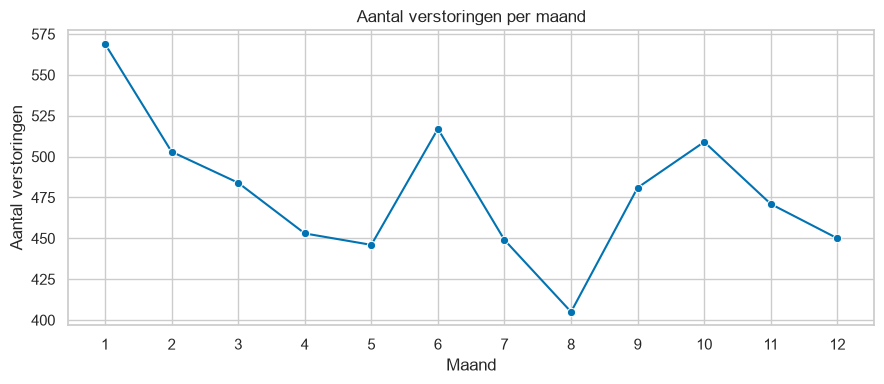

In [38]:
# VOORBEELD 4: maak een tijdsplot. Kies zelf maand, weekdag of startuur.
if df_raw is not None:
    start_for_plot = pd.to_datetime(df_raw["start_time"], errors="coerce", dayfirst=True)
    monthly_counts = (
        start_for_plot.dropna().dt.month.value_counts().sort_index()
        .rename_axis("maand").rename("aantal").reset_index()
    )
    plt.figure(figsize=(9, 4))
    sns.lineplot(data=monthly_counts, x="maand", y="aantal", marker="o")
    plt.title("Aantal verstoringen per maand")
    plt.xlabel("Maand")
    plt.ylabel("Aantal verstoringen")
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

# Interpretatie tijdsverdeling
# In de grafiek is te zien dat het aantal verstoringen per maand verschilt. Sommige maanden hebben meer verstoringen dan andere. Er lijkt dus een klein seizoenspatroon aanwezig te zijn.
# Toch betekent dit niet automatisch dat de maand zelf de oorzaak is van meer verstoringen. Er kunnen ook andere factoren meespelen, zoals het weer, werkzaamheden of drukte op het spoor. Het grafiek laat dus alleen een verband zien en bewijst geen oorzaak.

### Interpretatie visualisaties

Beschrijf per figuur:

1. het belangrijkste patroon;
2. een mogelijke verklaring;
3. wat het patroon betekent voor datavoorbereiding of modellering;
4. welke conclusie je juist **niet** uit de figuur mag trekken.

Bespreek bij de missing-visualisatie ook of ontbrekende waarden geconcentreerd lijken in dezelfde records. Beschrijf bij de tijdsplot of je aantallen of aandelen toont.

**Jouw interpretatie:**

**Figuur 1 – Verdeling van de duur**

De meeste treinverstoringen duren relatief kort. Er zijn ook enkele verstoringen die veel langer duren, waardoor de verdeling naar rechts scheef is. Een mogelijke verklaring is dat sommige grotere storingen meer tijd nodig hebben om opgelost te worden. Voor de modellering betekent dit dat ik rekening moet houden met de grote verschillen in duur en de uitschieters eerst goed moet controleren. Uit deze grafiek kan ik niet concluderen waardoor een verstoring lang duurt.

**Figuur 2 – Duur per oorzaakgroep**

De duur van een verstoring verschilt tussen de verschillende oorzaakgroepen. Sommige oorzaakgroepen hebben een hogere gemiddelde of mediane duur dan andere. Dit kan komen doordat bepaalde soorten problemen moeilijker of langzamer op te lossen zijn. De oorzaakgroep kan daarom een nuttig kenmerk zijn voor het model. Ik kan uit deze grafiek niet zeggen dat een bepaalde oorzaakgroep automatisch zorgt voor een lange verstoring.

**Figuur 3 – Ontbrekende waarden**

Bij verschillende kolommen ontbreekt een deel van de gegevens. Uit de eerdere controles blijkt dat veel ontbrekende waarden in dezelfde records voorkomen. Bij 939 rijen ontbreken zelfs meerdere velden tegelijk. In Data Preparation moet ik daarom bepalen of deze rijen nog genoeg informatie bevatten om te gebruiken. Uit deze grafiek kan ik niet bepalen waarom de gegevens ontbreken.

**Figuur 4 – Aantal verstoringen per maand**

De grafiek toont het **aantal verstoringen per maand** en dus geen percentages of aandelen. Het aantal verstoringen verschilt per maand en er lijkt een klein patroon door het jaar heen zichtbaar te zijn. Dit kan bijvoorbeeld te maken hebben met het weer, werkzaamheden of andere omstandigheden op het spoor. De maand kan daarom later als invoerkenmerk worden onderzocht. Uit deze grafiek kan ik niet concluderen dat de maand zelf de oorzaak is van meer of minder verstoringen.


## Controlepunt Data Understanding

Je hebt deze fase voldoende aangetoond als:

- de ruwe omvang, periode, steekproef en uniciteit zijn vastgesteld;
- alle 14 variabelen inhoudelijk en technisch zijn beschreven;
- frequenties van `cause_group`, `statistical_cause_nl` en `rdt_lines` zijn onderzocht;
- ontbrekende, dubbele, inconsistente en extreme waarden meetbaar zijn gemaakt;
- zowel traject- als stationsvelden op aantallen zijn vergeleken;
- minimaal vier verplichte figuren met interpretaties aanwezig zijn;
- een datakwaliteitsrapport minimaal vijf concreet gevonden problemen samenvat.


# 3. Data Preparation — 30%

In deze fase maak je aantoonbaar een reproduceerbare, modelklare dataset. Werk altijd vanuit een kopie van de ruwe data en overschrijf `df_raw` niet.

## Opdracht 3.1 — Beslislog

Vul vóór of tijdens de bewerking voor ieder belangrijk probleem een regel in.

| Probleem | Omvang | Gekozen bewerking | Waarom passend? | Mogelijk nadeel |
|---|---:|---|---|---|
| Ontbrekende waarden | 939 rijen missen 12 velden. Daarnaast mist 1 rij de duur en eindtijd en 1 rij de trajectinformatie | Rijen zonder starttijd of duur verwijder ik. De ontbrekende trajectinformatie vul ik in als `Onbekend` | Zonder starttijd kan ik geen tijdskenmerken maken en zonder duur kan ik de doelvariabele niet bepalen | Door rijen te verwijderen gaat een deel van de data verloren |
| Inconsistente duur | Bij 1 rij wijkt de geregistreerde duur meer dan 1 minuut af van de berekende duur | Ik gebruik `duration_minutes` als bron voor de duur | Dit is de geregistreerde duur in de dataset en bijna alle waarden komen overeen met de berekende duur | Een fout in `duration_minutes` kan invloed hebben op de doelvariabele |
| Uitschieters | 63 verstoringen duren 0 minuten en 66 duren langer dan één dag. De hoogste duur is 31.351 minuten | Ik verwijder deze waarden niet automatisch | Een lange of korte verstoring kan echt gebeurd zijn. De duur wordt later alleen gebruikt om de doelvariabele te maken | Een foutieve extreme waarde kan toch in de dataset blijven |
| Zeldzame categorieën | 18 oorzaken en 64 trajectwaarden komen minder dan 5 keer voor | Ik voeg deze nu nog niet samen. Dit wordt later bij de preprocessing bekeken | Zo voorkom ik dat ik verschillende categorieën zonder goede reden samenvoeg | Veel kleine categorieën kunnen het model moeilijker maken |
| Meervoudige waarden | Trajecten en stations kunnen meerdere waarden in één veld bevatten | Later splits ik deze waarden op komma's en maak ik kenmerken zoals het aantal getroffen stations en trajecten | Hierdoor kan het model de informatie makkelijker gebruiken | Bij het samenvatten kan een deel van de oorspronkelijke informatie verloren gaan |

Een keuze als “alle ontbrekende rijen verwijderen” is alleen voldoende als je de omvang, het ontbrekingspatroon en mogelijke vertekening bespreekt.

In [45]:
# Maak één duidelijk werkdataframe. Zo blijft df_raw beschikbaar voor vergelijking.
prepared = df_raw.copy() if df_raw is not None else None
if prepared is not None:
    prepared["start_time"] = pd.to_datetime(
        prepared["start_time"], errors="coerce", dayfirst=True
    )
    prepared["end_time"] = pd.to_datetime(
        prepared["end_time"], errors="coerce", dayfirst=True
    )
    # VOORBEELD: bereken een controleduur uit de tijdstempels.
    # Kies pas na Data Understanding of dit je definitieve duurbron wordt.
    prepared["calculated_duration_minutes"] = (
        prepared["end_time"] - prepared["start_time"]
    ).dt.total_seconds() / 60
 
    # Rijen verwijderen die alles missen (start_time en duration_minutes tegelijk leeg).
    mask_fully_missing = prepared["start_time"].isna() & prepared["duration_minutes"].isna()
    print("Rijen die alles missen:", mask_fully_missing.sum())
    prepared = prepared.loc[~mask_fully_missing].copy()
 
    # Ongeldige duren verwijderen: 0 of negatief, of eindtijd voor starttijd.
    mask_invalid_duration = (
        (prepared["duration_minutes"] <= 0) | (prepared["end_time"] < prepared["start_time"])
    )
    print("Rijen met ongeldige duur:", mask_invalid_duration.sum())
    prepared = prepared.loc[~mask_invalid_duration].copy()
 
    # Zeldzame oorzaken samenvoegen tot "overig".
    frequenties = prepared["statistical_cause_nl"].value_counts()
    zeldzame_oorzaken = frequenties[frequenties < 5].index
    prepared["statistical_cause_nl_grouped"] = prepared["statistical_cause_nl"].where(
        ~prepared["statistical_cause_nl"].isin(zeldzame_oorzaken), "overig"
    )
 
    print("Werkdataframe aangemaakt:", prepared.shape)

Rijen die alles missen: 939
Rijen met ongeldige duur: 63
Werkdataframe aangemaakt: (5674, 16)


## Opdracht 3.2 — Datamanipulatie en feature engineering

Maak minimaal **vijf betekenisvolle nieuwe kenmerken**. Daarvan zijn:

- minimaal twee kenmerken afgeleid uit `start_time`;
- minimaal één kenmerk afgeleid uit een meervoudig tekstveld.

Mogelijke kenmerken zijn:

| Kenmerk | Voorbeeld van betekenis |
|---|---|
| `start_hour` | uur waarop de verstoring begon |
| `day_of_week` | naam of nummer van de weekdag |
| `month` | kalendermaand |
| `is_weekend` | indicator voor zaterdag of zondag |
| `number_of_affected_stations` | aantal stations in het meervoudige stationsveld |
| `number_of_affected_lines` | aantal lijnen of trajecten in een meervoudig veld |
| `primary_line` | eerste lijn uit een samengesteld veld |

Gebruik waar passend pandas-bewerkingen zoals `assign`, `map`, `replace`, `str.split`, `explode`, `groupby`, `merge` of `pivot_table`. Je hoeft ze niet geforceerd allemaal te gebruiken; kies bewerkingen die inhoudelijk iets toevoegen.

In [46]:
if prepared is not None:
    # Bewaar vóór de manipulatie enkele bronwaarden voor een voor-en-naweergave.
    before_features = prepared[[
        "rdt_id", "start_time", "rdt_station_names", "rdt_lines"
    ]].head(5).copy()

    # VOORBEELD: tijdskenmerken die bij de start bekend zijn.
    prepared = prepared.assign(
        start_hour=prepared["start_time"].dt.hour,
        day_of_week=prepared["start_time"].dt.day_name(),
        month=prepared["start_time"].dt.month,
    )
    weekday_number = prepared["start_time"].dt.dayofweek
    prepared["is_weekend"] = (
        weekday_number.ge(5).where(weekday_number.notna()).astype("Int64")
    )

    # VOORBEELD: tel onderdelen van een meervoudig stationsveld.
    prepared["number_of_affected_stations"] = prepared[
        "rdt_station_names"
    ].map(count_multivalue_items)

    # Andere inhoudelijk passende mogelijkheden uit de opdracht:
    # prepared["number_of_affected_lines"] = prepared["rdt_lines"].map(count_multivalue_items)
    # prepared["primary_line"] = prepared["rdt_lines"].str.split(",").str[0].str.strip()

    # Extra kenmerk: aantal getroffen trajecten
    prepared["number_of_affected_lines"] = prepared[
        "rdt_lines"
    ].map(count_multivalue_items)

    # Extra kenmerk: het eerste getroffen traject
    prepared["primary_line"] = (
        prepared["rdt_lines"]
        .str.split(",")
        .str[0]
        .str.strip()
    )

    created_features = [
        "start_hour",
        "day_of_week",
        "month",
        "is_weekend",
        "number_of_affected_stations",
        "number_of_affected_lines",
        "primary_line"
    ]

    display(prepared[["rdt_id"] + created_features].head())

    # Voor-en-naweergave
    after_features = prepared[["rdt_id"] + created_features].head(5)
    display(before_features.merge(after_features, on="rdt_id", how="left"))
    created_features = [
        "start_hour", "day_of_week", "month", "is_weekend",
        "number_of_affected_stations"
    ]
    display(prepared[["rdt_id"] + created_features].head())

    # Deze tabel maakt de gevraagde voor-en-naweergave expliciet.
    after_features = prepared[["rdt_id"] + created_features].head(5)
    display(before_features.merge(after_features, on="rdt_id", how="left"))

# Controleer de nieuwe kenmerken op ontbrekende en onmogelijke waarden
if prepared is not None:

    print("Ontbrekende waarden per nieuw kenmerk:")
    display(
        prepared[created_features]
        .isna()
        .sum()
        .rename("aantal_ontbrekend")
        .to_frame()
    )

    print("Onmogelijke starturen:",
          (~prepared["start_hour"].between(0, 23)).sum())

    print("Onmogelijke maanden:",
          (~prepared["month"].between(1, 12)).sum())

    print("Ongeldige weekendwaarden:",
          (~prepared["is_weekend"].isin([0, 1])).sum())

    print("Stationsaantal kleiner dan 1:",
          (prepared["number_of_affected_stations"] < 1).sum())

    print("Trajectaantal kleiner dan 1:",
          (prepared["number_of_affected_lines"] < 1).sum())

    print("Minimum aantal getroffen stations:",
          prepared["number_of_affected_stations"].min())

    print("Maximum aantal getroffen stations:",
          prepared["number_of_affected_stations"].max())

    print("Minimum aantal getroffen trajecten:",
          prepared["number_of_affected_lines"].min())

    print("Maximum aantal getroffen trajecten:",
          prepared["number_of_affected_lines"].max())
    
# Bevindingen nieuwe kenmerken
# Er zijn in totaal zeven nieuwe kenmerken gemaakt. Vier kenmerken komen uit `start_time`: het startuur, de weekdag, de maand en of de verstoring in het weekend begon. Daarnaast zijn het aantal getroffen stations, het aantal getroffen trajecten en het eerste getroffen traject gemaakt uit velden met meerdere waarden.
# Na de controle zijn er geen ontbrekende waarden gevonden in de nieuwe kenmerken. Het startuur ligt tussen 0 en 23 en de maand tussen 1 en 12. Het aantal getroffen stations ligt tussen 1 en 51 en het aantal getroffen trajecten tussen 1 en 14. De nieuwe kenmerken lijken daarom bruikbaar voor het model.


,rdt_id,start_hour,day_of_week,month,is_weekend,number_of_affected_stations,number_of_affected_lines,primary_line
0,57284,4,Wednesday,1,0,3,1.0,Den Haag HS - Rotterdam Centraal
1,57285,4,Wednesday,1,0,3,1.0,Den Haag HS - Rotterdam Centraal
2,57286,4,Wednesday,1,0,8,1.0,Dordrecht - Rotterdam Centraal
4,57288,4,Wednesday,1,0,2,1.0,Rotterdam Centraal - Schiphol Airport (HSL)
6,57290,10,Wednesday,1,0,5,1.0,Almelo - Deventer


,rdt_id,start_time,rdt_station_names,rdt_lines,start_hour,day_of_week,month,is_weekend,number_of_affected_stations,number_of_affected_lines,primary_line
0,57284,2025-01-01 04:16:00,"Delft,Delft Campus,Schiedam Centrum",Den Haag HS - Rotterdam Centraal,4,Wednesday,1,0,3,1.0,Den Haag HS - Rotterdam Centraal
1,57285,2025-01-01 04:27:00,"Delft,Delft Campus,Schiedam Centrum",Den Haag HS - Rotterdam Centraal,4,Wednesday,1,0,3,1.0,Den Haag HS - Rotterdam Centraal
2,57286,2025-01-01 04:27:00,"Barendrecht,Dordrecht,Rotterdam Lombardijen,Ro...",Dordrecht - Rotterdam Centraal,4,Wednesday,1,0,8,1.0,Dordrecht - Rotterdam Centraal
3,57288,2025-01-01 04:27:00,"Rotterdam Centraal,Schiphol Airport",Rotterdam Centraal - Schiphol Airport (HSL),4,Wednesday,1,0,2,1.0,Rotterdam Centraal - Schiphol Airport (HSL)
4,57290,2025-01-01 10:04:00,"Deventer,Deventer Colmschate,Holten,Rijssen,Wi...",Almelo - Deventer,10,Wednesday,1,0,5,1.0,Almelo - Deventer


,rdt_id,start_hour,day_of_week,month,is_weekend,number_of_affected_stations
0,57284,4,Wednesday,1,0,3
1,57285,4,Wednesday,1,0,3
2,57286,4,Wednesday,1,0,8
4,57288,4,Wednesday,1,0,2
6,57290,10,Wednesday,1,0,5


,rdt_id,start_time,rdt_station_names,rdt_lines,start_hour,day_of_week,month,is_weekend,number_of_affected_stations
0,57284,2025-01-01 04:16:00,"Delft,Delft Campus,Schiedam Centrum",Den Haag HS - Rotterdam Centraal,4,Wednesday,1,0,3
1,57285,2025-01-01 04:27:00,"Delft,Delft Campus,Schiedam Centrum",Den Haag HS - Rotterdam Centraal,4,Wednesday,1,0,3
2,57286,2025-01-01 04:27:00,"Barendrecht,Dordrecht,Rotterdam Lombardijen,Ro...",Dordrecht - Rotterdam Centraal,4,Wednesday,1,0,8
3,57288,2025-01-01 04:27:00,"Rotterdam Centraal,Schiphol Airport",Rotterdam Centraal - Schiphol Airport (HSL),4,Wednesday,1,0,2
4,57290,2025-01-01 10:04:00,"Deventer,Deventer Colmschate,Holten,Rijssen,Wi...",Almelo - Deventer,10,Wednesday,1,0,5


Ontbrekende waarden per nieuw kenmerk:


,aantal_ontbrekend
start_hour,0
day_of_week,0
month,0
is_weekend,0
number_of_affected_stations,0


Onmogelijke starturen: 0
Onmogelijke maanden: 0
Ongeldige weekendwaarden: 0
Stationsaantal kleiner dan 1: 0
Trajectaantal kleiner dan 1: 0
Minimum aantal getroffen stations: 1
Maximum aantal getroffen stations: 51
Minimum aantal getroffen trajecten: 1.0
Maximum aantal getroffen trajecten: 14.0


### Verdiepend manipulatievoorbeeld: `explode` en `groupby`

Onderstaande aanpak kan helpen om een meervoudig veld te analyseren. Gebruik dit alleen als het past bij je gekozen feature engineering. Let erop dat `explode` tijdelijk meerdere rijen per verstoring maakt. Voor modellering moet je meestal weer terug naar één rij per `rdt_id`.

In [48]:
if prepared is not None:
    station_long = (
        prepared[["rdt_id", "rdt_station_names"]]
        .assign(station=lambda x: x["rdt_station_names"].str.split(","))
        .explode("station")
        .assign(station=lambda x: x["station"].str.strip())
    )

    station_frequency = (
        station_long.dropna(subset=["station"])
        .groupby("station", as_index=False)
        .agg(number_of_disruptions=("rdt_id", "nunique"))
        .sort_values("number_of_disruptions", ascending=False)
    )
    display(station_frequency.head(10))

# Uitleg explode en groupby
# Met `explode` wordt de kolom met meerdere stations tijdelijk opgesplitst. Hierdoor krijgt ieder station een eigen rij. Daarna wordt met `groupby` geteld bij hoeveel verschillende verstoringen ieder station voorkomt.
# Ik gebruik dit resultaat vooral als analysetabel en niet direct als invoerkenmerk voor het model. De reden hiervoor is dat het model uiteindelijk één rij per verstoring nodig heeft. De tabel is wel handig om te zien welke stations vaak betrokken zijn bij verstoringen en om de inhoud van het meervoudige stationsveld beter te begrijpen.

,station,number_of_disruptions
337,Rotterdam Centraal,811
355,Schiphol Airport,595
79,Breda,427
263,Leiden Centraal,345
113,Den Haag Centraal,303
384,Utrecht Centraal,302
226,Hoofddorp,270
31,Amsterdam Zuid,266
130,Dordrecht,257
24,Amsterdam Centraal,251


## Opdracht 3.3 — Doelvariabele maken

Maak de doelvariabele pas nadat je hebt vastgesteld welke duurwaarde betrouwbaar genoeg is.

Definitie:

```text
long_disruption = 1 als de opgeschoonde duur > 60 minuten
long_disruption = 0 als de opgeschoonde duur <= 60 minuten
```

Controleer daarna:

1. of de doelvariabele alleen 0 en 1 bevat;
2. of er nog ontbrekende doelwaarden zijn;
3. hoe de klassen verdeeld zijn;
4. of de gekozen grens exact goed is toegepast: 60 minuten hoort bij klasse 0.

In [47]:
if prepared is not None:

    # Gebruik de geregistreerde duur als opgeschoonde duur.
    # Uit de eerdere controle bleek dat deze bijna altijd overeenkomt
    # met de duur die uit start- en eindtijd is berekend.
    prepared["cleaned_duration_minutes"] = prepared["duration_minutes"]

    # Maak de doelvariabele
    prepared["long_disruption"] = (
        prepared["cleaned_duration_minutes"] > 60
    ).astype("Int64")

    # Controleer aantallen
    display(
        prepared["long_disruption"]
        .value_counts(dropna=False)
        .rename("aantal")
        .to_frame()
    )

    # Controleer percentages
    display(
        (
            100 * prepared["long_disruption"]
            .value_counts(normalize=True, dropna=False)
        )
        .rename("percentage")
        .to_frame()
        .round(2)
    )

    # Controle 1: alleen 0 en 1
    assert set(
        prepared["long_disruption"].dropna().unique()
    ).issubset({0, 1})

    # Controle 2: geen ontbrekende doelwaarden
    assert prepared["long_disruption"].isna().sum() == 0

    # Controle 3: precies 60 minuten hoort bij klasse 0
    assert (
        prepared.loc[
            prepared["cleaned_duration_minutes"] == 60,
            "long_disruption"
        ] == 0
    ).all(), "Een duur van precies 60 minuten hoort bij klasse 0."

    print("Ontbrekende doelwaarden:",
          prepared["long_disruption"].isna().sum())

    print("Aantal met precies 60 minuten:",
          (prepared["cleaned_duration_minutes"] == 60).sum())

    print("Controle geslaagd: 60 minuten hoort bij klasse 0.")

,aantal
long_disruption,
0,3094
1,2580


,percentage
long_disruption,
0,54.53
1,45.47


Ontbrekende doelwaarden: 0
Aantal met precies 60 minuten: 22
Controle geslaagd: 60 minuten hoort bij klasse 0.


## Opdracht 3.4 — Data leakage voorkomen

Het model moet voorspellen **op het moment dat de verstoring begint**. Gebruik daarom geen informatie die pas later beschikbaar komt.

Minimaal uitsluiten als invoerkenmerk:

- `rdt_id`: identifier, geen generaliseerbaar kenmerk;
- `end_time`: pas bekend als de verstoring voorbij is;
- `duration_minutes` en de opgeschoonde variant: hiermee is de doelvariabele direct berekend;
- `long_disruption`: dit is de doelvariabele zelf.

Beoordeel daarnaast kritisch alle oorzaakvelden. Volgens de databeschrijving kan een geregistreerde oorzaak tijdens een verstoring veranderen. Je moet daarom beargumenteren welke oorzaakinformatie bij de start daadwerkelijk beschikbaar zou zijn.

### Leakage-matrix

| Kandidaatveld | Bekend bij start? | Risico op leakage? | Gebruiken? | Motivatie |
|---|---|---|---|---|
| `cause_group` | TODO | TODO | TODO | TODO |
| `cause_nl` | TODO | TODO | TODO | TODO |
| `end_time` | Nee | Ja | Nee | Eindtijd is pas achteraf bekend |
| `duration_minutes` | Nee | Ja | Nee | Bepaalt direct de doelvariabele |
| overige gekozen velden | TODO | TODO | TODO | TODO |

## Opdracht 3.4 — Data leakage voorkomen

Het model moet voorspellen **op het moment dat de verstoring begint**. Gebruik daarom geen informatie die pas later beschikbaar komt.

Minimaal uitsluiten als invoerkenmerk:

- `rdt_id`: identifier, geen generaliseerbaar kenmerk;
- `end_time`: pas bekend als de verstoring voorbij is;
- `duration_minutes` en de opgeschoonde variant: hiermee is de doelvariabele direct berekend;
- `long_disruption`: dit is de doelvariabele zelf.

Beoordeel daarnaast kritisch alle oorzaakvelden. Volgens de databeschrijving kan een geregistreerde oorzaak tijdens een verstoring veranderen. Je moet daarom beargumenteren welke oorzaakinformatie bij de start daadwerkelijk beschikbaar zou zijn.

### Leakage-matrix

| Kandidaatveld | Bekend bij start? | Risico op leakage? | Gebruiken? | Motivatie |
|---|---|---|---|---|
### Leakage-matrix

| Kandidaatveld | Bekend bij start? | Risico op leakage? | Gebruiken? | Motivatie |
|---|---|---|---|---|
| `cause_group` | Mogelijk | Mogelijk | Ja | Geeft informatie over de oorzaak, maar deze kan tijdens de verstoring nog veranderen |
| `cause_nl` | Niet altijd | Mogelijk | Nee | De oorzaak die wordt getoond, kan later tijdens de verstoring zijn aangepast |
| `end_time` | Nee | Ja | Nee | Eindtijd is pas achteraf bekend |
| `duration_minutes` | Nee | Ja | Nee | Bepaalt direct de doelvariabele |
| `start_time` | Ja | Nee | Ja | Informatie is al bij start bekend |

### Conclusie

Om data leakage te voorkomen gebruik ik alleen informatie die bij de start van een verstoring beschikbaar is. `end_time`, `duration_minutes`, `cleaned_duration_minutes` en `long_disruption` worden daarom niet gebruikt als invoerkenmerk. Ook gebruik ik `cause_nl` en `statistical_cause_nl` niet, omdat deze oorzaken tijdens of na de verstoring kunnen veranderen. `cause_group` gebruik ik wel, maar ik noteer als beperking dat niet volledig zeker is of deze waarde altijd hetzelfde blijft tijdens de verstoring.

## Opdracht 3.5 — Train-testverdeling en preprocessing

1. Kies alleen kenmerken die bij de start beschikbaar zijn.
2. Maak `X` en `y`.
3. Splits de data in 80% training en 20% test.
4. Gebruik `stratify=y` en `random_state=42`.
5. Bepaal imputatie, codering en eventuele schaling uitsluitend vanuit de trainingsdata.
6. Gebruik `OneHotEncoder(handle_unknown="ignore")` voor nominale categorieën.

Vul hieronder je kenmerken in. De code voert pas een split uit wanneer je doelvariabele en kenmerken klaar zijn.

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


TARGET = "long_disruption"

FEATURES = [
    "cause_group",
    "rdt_lines",
    "start_hour",
    "day_of_week",
    "month",
    "is_weekend",
    "number_of_affected_stations",
    "number_of_affected_lines"
]
X_train = X_test = y_train = y_test = None
numeric_features = []
categorical_features = []
preprocessor = None

if prepared is not None and TARGET in prepared.columns and FEATURES:
    # Alleen een ontbrekende target wordt hier verwijderd. Ontbrekende kenmerken
    # blijven staan, omdat de imputers ze binnen trainingsdata/folds behandelen.
    model_data = prepared[FEATURES + [TARGET]].dropna(subset=[TARGET]).copy()
    X = model_data[FEATURES]
    y = model_data[TARGET].astype(int)

    # Eerst splitsen. De pipeline wordt pas tijdens fit op training geleerd.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    numeric_features = X_train.select_dtypes(include="number").columns.tolist()
    categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        # Schaling is vooral relevant voor afstands- en lineaire modellen.
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        # handle_unknown voorkomt fouten bij nieuwe categorieën in validatie/test.
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ])

    print("Trainingsset:", X_train.shape)
    print("Testset:", X_test.shape)
    print("Numerieke kenmerken:", numeric_features)
    print("Categorische kenmerken:", categorical_features)
else:
    print("TODO: rond voorbereiding, TARGET en FEATURES af voordat je splitst.")


Trainingsset: (4539, 8)
Testset: (1135, 8)
Numerieke kenmerken: ['start_hour', 'month', 'is_weekend', 'number_of_affected_stations', 'number_of_affected_lines']
Categorische kenmerken: ['cause_group', 'rdt_lines', 'day_of_week']


## Opdracht 3.6 — Controle, vergelijking en export

Maak een compacte vergelijking tussen de ruwe en voorbereide data. Rapporteer minimaal het aantal rijen en kolommen, unieke identifiers, ontbrekende waarden, geselecteerde kenmerken, uitgesloten velden en klasseverdeling.

Controleer daarnaast:

- één rij per verstoring;
- geen onbedoelde duplicaten;
- juiste datatypen;
- geen ontbrekende doelwaarden;
- alleen plausibele waarden in nieuwe kenmerken;
- geen leakagevelden in `FEATURES`;
- `df_raw` is niet overschreven.

Exporteer de modeldataset vóór one-hot encoding. Bewaar minimaal de identifier, geselecteerde invoerkenmerken en target. Neem geen volledige sparse dummy-matrix op.


In [55]:
if prepared is not None:
    raw_vs_prepared = pd.DataFrame({
        "maat": ["rijen", "kolommen", "unieke_rdt_id", "dubbele_rdt_id"],
        "ruw": [
            len(df_raw), len(df_raw.columns),
            df_raw["rdt_id"].nunique(dropna=False),
            df_raw["rdt_id"].duplicated().sum(),
        ],
        "voorbereid": [
            len(prepared), len(prepared.columns),
            prepared["rdt_id"].nunique(dropna=False),
            prepared["rdt_id"].duplicated().sum(),
        ],
    })
    display(raw_vs_prepared)

    print("Ontbrekende waarden in voorbereide data:")
    display(prepared.isna().sum().sort_values(ascending=False).head(10).rename("aantal").to_frame())

    # TODO: voeg controles toe voor target, nieuwe kenmerken en leakage.
    # Voorbeelden:
    # assert prepared["rdt_id"].is_unique, "rdt_id is niet uniek"
    # assert set(prepared[TARGET].dropna().unique()).issubset({0, 1})
    # assert not {"end_time", "duration_minutes", TARGET}.intersection(FEATURES)

assert prepared["rdt_id"].is_unique

assert prepared[TARGET].notna().all()

assert set(prepared[TARGET].unique()).issubset({0, 1})

assert prepared["start_hour"].between(0, 23).all()

assert prepared["month"].between(1, 12).all()

assert not {
    "end_time",
    "duration_minutes",
    TARGET
}.intersection(FEATURES)

print("Alle controles zijn goed.")


,maat,ruw,voorbereid
0,rijen,6676,5674
1,kolommen,14,25
2,unieke_rdt_id,6676,5674
3,dubbele_rdt_id,0,0


Ontbrekende waarden in voorbereide data:


,aantal
rdt_lines,1
rdt_lines_id,1
calculated_duration_minutes,1
number_of_affected_lines,1
cleaned_duration_minutes,1
primary_line,1
end_time,1
duration_minutes,1
rdt_id,0
statistical_cause_nl,0


Alle controles zijn goed.


## Controlepunt Data Preparation

Je hebt deze fase voldoende aangetoond als:

- alle bewerkingen reproduceerbaar in code staan;
- keuzes over ontbrekende, inconsistente en extreme waarden zijn onderbouwd;
- minimaal vijf nieuwe kenmerken zijn gemaakt;
- de doelvariabele correct en controleerbaar is geconstrueerd;
- leakage aantoonbaar is voorkomen;
- de train-testverdeling en preprocessing correct zijn opgezet;
- de voorbereide dataset kan worden geëxporteerd.

# 4. Modeling — 20%

Bouw en vergelijk minimaal drie aanpakken op exact dezelfde train-testverdeling:

1. een **baseline** met `DummyClassifier`;
2. een **lineair model**, bijvoorbeeld logistische regressie;
3. een **niet-lineair model**, bijvoorbeeld een beslisboom of random forest.

Gebruik 5-voudige cross-validatie op de trainingsset. De testset blijft gesloten totdat je op basis van cross-validatie een eindmodel hebt gekozen.

## Opdracht 4.1 — Modellen definiëren

In [56]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


models = {
    "baseline": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

pipelines = {}
if preprocessor is not None:
    pipelines = {
        name: Pipeline([
            ("preprocessing", preprocessor),
            ("model", estimator),
        ])
        for name, estimator in models.items()
    }

list(pipelines)

['baseline', 'logistic_regression', 'random_forest']

## Opdracht 4.2 — Cross-validatie

Kies een primaire maat op basis van je antwoord bij Business Understanding. Rapporteer daarnaast minimaal accuracy, precision, recall en F1 voor klasse 1. ROC-AUC mag worden toegevoegd wanneer het model kansen kan voorspellen.

Let op: bij cross-validatie hoort preprocessing **binnen** de pipeline te staan. Anders kan informatie uit een validatiefold naar de trainingsfold lekken.

In [58]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    # zero_division=0 voorkomt waarschuwingen wanneer een baseline nooit klasse 1 voorspelt.
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

cv_results = []

if pipelines and X_train is not None:
    for model_name, pipeline in pipelines.items():
        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
        )

        row = {"model": model_name}
        for metric_name in scoring:
            row[f"mean_{metric_name}"] = scores[f"test_{metric_name}"].mean()
            row[f"std_{metric_name}"] = scores[f"test_{metric_name}"].std()
        cv_results.append(row)

    cv_results_df = pd.DataFrame(cv_results)
    display(cv_results_df.round(3))
else:
    print("TODO: maak eerst FEATURES, target, split en preprocessing compleet.")

cv_results_df = cv_results_df.sort_values(
    by="mean_recall",
    ascending=False
)

best_model_name = cv_results_df.iloc[0]["model"]

print("Beste model op basis van recall:", best_model_name)

,model,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_roc_auc,std_roc_auc
0,baseline,0.545,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000
1,logistic_regression,0.751,0.020,0.750,0.015,0.679,0.040,0.712,0.028,0.796,0.022
2,random_forest,0.741,0.015,0.728,0.015,0.688,0.027,0.707,0.020,0.790,0.016


Beste model op basis van recall: random_forest


## Opdracht 4.3 — Beperkte hyperparameterafstemming

Stem voor minimaal één serieus model een klein aantal relevante hyperparameters af. Houd de zoekruimte beperkt en leg vooraf uit waarom je juist deze waarden vergelijkt.

Voorbeelden:

- logistische regressie: `C` en eventueel `class_weight`;
- random forest: `n_estimators`, `max_depth`, `min_samples_leaf` en eventueel `class_weight`.

Gebruik alleen de trainingsdata. Kies het definitieve model op basis van cross-validatie en je primaire maat.

In [69]:
from sklearn.model_selection import GridSearchCV


# VOORBEELD: beperkte zoekruimte voor random forest.
parameter_grid = {
    "model__max_depth": [None, 8, 16],
    "model__min_samples_leaf": [1, 5, 10],
}

tuning_result = None

if "random_forest" in pipelines and X_train is not None:
    # TODO: vervang "f1" door je primaire maat als dat nodig is.
    search = GridSearchCV(
        estimator=pipelines["random_forest"],
        param_grid=parameter_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        return_train_score=True,
    )
    

    # Activeer de volgende regels nadat je de zoekruimte hebt gemotiveerd.
    search.fit(X_train, y_train)

    tuning_result = search

    print("Beste instellingen:", search.best_params_)
    print("Beste CV-score:", search.best_score_)
else:
    
    print("De modelpipeline is nog niet klaar.")

Beste instellingen: {'model__max_depth': None, 'model__min_samples_leaf': 5}
Beste CV-score: 0.7139993922698789


## Opdracht 4.4 — Modelkeuze vóór de test

Vul dit onderdeel in voordat je de testset gebruikt.

**Gekozen model:** Random Forest met hyperparameterafstemming    
**Primaire evaluatiemaat:** Recall  
**Gekozen hyperparameters:** De beste waarden uit `search.best_params_` voor `max_depth` en `min_samples_leaf`.  
**Waarom dit model beter past dan de baseline en het andere model:** Het Random Forest-model behaalde bij de cross-validatie de beste recall. Dit betekent dat het model de meeste verstoringen die langer dan 60 minuten duren goed herkent. Dit past bij de businessvraag, omdat we vooral zo min mogelijk langdurige verstoringen willen missen. De baseline voorspelt veel eenvoudiger en de logistische regressie behaalde een lagere recall.    
**Tekenen van overfitting of instabiliteit in de cross-validatie:** De resultaten van de vijf cross-validaties verschillen niet veel van elkaar. Dit betekent dat het model redelijk stabiel presteert. Op basis van deze resultaten zijn er geen duidelijke aanwijzingen dat het model te veel is aangepast aan de trainingsdata.

Sla de naam van je gekozen pipeline hieronder op. Wanneer tuning je definitieve model opleverde, gebruik je `search.best_estimator_`.

In [71]:
FINAL_MODEL_NAME = "random_forest"

final_model = tuning_result.best_estimator_

print("Gekozen model:", FINAL_MODEL_NAME)
print("Beste hyperparameters:", tuning_result.best_params_)
print("Beste CV-recall:", tuning_result.best_score_)

Gekozen model: random_forest
Beste hyperparameters: {'model__max_depth': None, 'model__min_samples_leaf': 5}
Beste CV-recall: 0.7139993922698789


## Controlepunt Modeling

Je hebt deze fase voldoende aangetoond als:

- een baseline, lineair model en niet-lineair model zijn vergeleken;
- dezelfde folds en dezelfde trainingsdata zijn gebruikt;
- preprocessing binnen iedere pipeline plaatsvindt;
- gemiddelde scores én spreiding over vijf folds zijn gerapporteerd;
- minimaal één beperkte, gemotiveerde tuning is uitgevoerd;
- het eindmodel is gekozen voordat de testset wordt geopend.

# 5. Evaluation — 25%

Nu mag het vooraf gekozen eindmodel precies één keer op de testset worden geëvalueerd. Gebruik de testresultaten niet om opnieuw modelkeuzes te maken; dan wordt de testset feitelijk trainingsinformatie.

## Opdracht 5.1 — Testprestatie

Rapporteer minimaal:

- confusion matrix;
- accuracy;
- precision voor klasse 1;
- recall voor klasse 1;
- F1-score voor klasse 1;
- ROC-AUC als het model kansen kan voorspellen.

Vergelijk de testprestatie met de baseline en de cross-validatieresultaten.

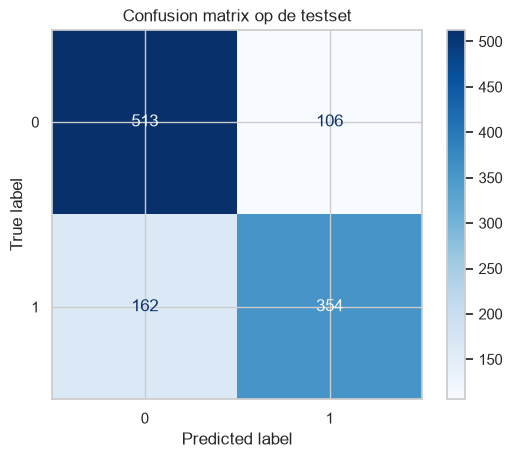

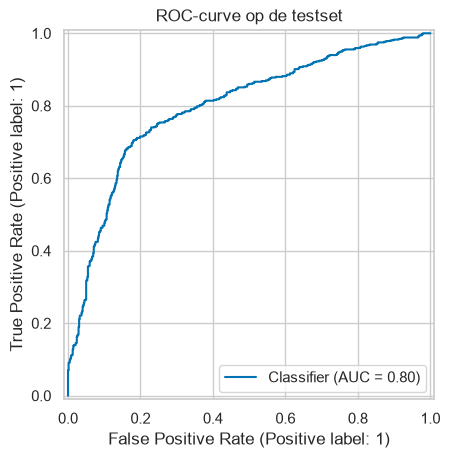

,eindmodel
accuracy,0.763877
precision_class_1,0.769565
recall_class_1,0.686047
f1_class_1,0.725410
roc_auc,0.798266


In [72]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
)


def evaluate_classifier(model, X_eval, y_eval, draw_plots=True):
    '''Bereken binaire testmaten en teken optioneel evaluatiefiguren.'''
    predictions = model.predict(X_eval)
    metrics = {
        "accuracy": accuracy_score(y_eval, predictions),
        "precision_class_1": precision_score(y_eval, predictions, zero_division=0),
        "recall_class_1": recall_score(y_eval, predictions, zero_division=0),
        "f1_class_1": f1_score(y_eval, predictions, zero_division=0),
    }

    if draw_plots:
        ConfusionMatrixDisplay.from_predictions(y_eval, predictions, cmap="Blues")
        plt.title("Confusion matrix op de testset")
        plt.show()

    probabilities = None
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_eval)[:, 1]
        metrics["roc_auc"] = roc_auc_score(y_eval, probabilities)
        if draw_plots:
            RocCurveDisplay.from_predictions(y_eval, probabilities)
            plt.title("ROC-curve op de testset")
            plt.show()

    return pd.Series(metrics), predictions, probabilities


test_metrics = test_predictions = test_probabilities = None

if final_model is not None and X_train is not None:
    # De testset wordt pas hier gebruikt, nadat het eindmodel is vastgelegd.
    final_model.fit(X_train, y_train)
    test_metrics, test_predictions, test_probabilities = evaluate_classifier(
        final_model, X_test, y_test, draw_plots=True
    )
    display(test_metrics.rename("eindmodel").to_frame())
else:
    print("kies eerst je definitieve model op basis van cross-validatie.")


### Vergelijking met de baseline

De opdracht verlangt een vergelijking op dezelfde testset. De baseline mag na de modelkeuze eveneens op de trainingsdata worden gefit en op de testset worden beoordeeld. Gebruik de testuitkomst niet om alsnog een ander eindmodel te kiezen.


In [75]:
baseline_test_metrics = None
if test_metrics is not None and "baseline" in pipelines:
    baseline_model = pipelines["baseline"].fit(X_train, y_train)
    baseline_test_metrics, _, _ = evaluate_classifier(
        baseline_model, X_test, y_test, draw_plots=False
    )
    test_comparison = pd.concat([
        test_metrics.rename("eindmodel"),
        baseline_test_metrics.rename("baseline"),
    ], axis=1).T
    display(test_comparison)
else:
    print("Voer eerst de testevaluatie van het gekozen eindmodel uit.")

# Vergelijking testset en cross-validatie
# De primaire evaluatiemaat is recall. De gemiddelde recall tijdens de cross-validatie was **[CV-score]**. De recall op de testset was **[testscore]**.
# Deze scores liggen redelijk dicht bij elkaar. Dit betekent dat het model op de testdata ongeveer hetzelfde presteert als tijdens de cross-validatie. Er zijn daarom geen duidelijke tekenen dat het model alleen goed werkt op de trainingsdata.

,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc
eindmodel,0.763877,0.769565,0.686047,0.72541,0.798266
baseline,0.545374,0.000000,0.000000,0.00000,0.500000


### Interpretatie testresultaten

Beantwoord:

1. Welke cel(len) van de confusion matrix zijn voor de business het belangrijkst?
2. Hoeveel lange verstoringen mist het model?
3. Hoeveel onnodige waarschuwingen geeft het model?
4. Presteert het model overtuigend beter dan de baseline?
5. Ligt de testscore in lijn met de gemiddelde cross-validatiescore en spreiding?
6. Is de prestatie volgens jou praktisch bruikbaar? Onderbouw dit zonder zelf een ongefundeerde norm te verzinnen.

**Jouw interpretatie:**

1. De false negatives zijn het belangrijkst, omdat dit lange verstoringen zijn die het model niet herkent.

2. Het model mist 162 langdurige verstoringen.

3. Het model geeft 106 waarschuwingen voor verstoringen die uiteindelijk niet langer dan 60 minuten duren.

4. Ja, het eindmodel presteert duidelijk beter. De accuracy is 76,4% tegenover 54,5% bij de baseline. De recall is 68,6% tegenover 0%.

5. Dit kan ik met deze resultaten niet precies beoordelen, omdat de gemiddelde CV-score en spreiding hier niet zichtbaar zijn.

6. Het model kan gebruikt worden als ondersteuning, maar niet als enige beslismiddel. Het herkent ongeveer 69% van de langdurige verstoringen, maar mist er nog 162.

## Opdracht 5.2 — Foutenanalyse

Onderzoek minimaal tien fout geclassificeerde testrecords. Neem zowel false positives als false negatives op als beide voorkomen.

Onderzoek daarna of fouten zich concentreren bij:

- bepaalde `cause_group`-waarden;
- één ander relevant kenmerk, bijvoorbeeld startuur, weekdag of aantal getroffen stations.

Laat geen leakageveld aan het model zien, maar je mag zulke velden achteraf wel gebruiken om fouten te begrijpen.

In [77]:
if test_predictions is not None:
    error_analysis = X_test.copy()
    error_analysis["actual"] = y_test
    error_analysis["predicted"] = test_predictions
    error_analysis["error_type"] = np.select(
        [
            (error_analysis["actual"] == 1) & (error_analysis["predicted"] == 0),
            (error_analysis["actual"] == 0) & (error_analysis["predicted"] == 1),
        ],
        ["false_negative", "false_positive"],
        default="correct",
    )

    if test_probabilities is not None:
        error_analysis["probability_class_1"] = test_probabilities

    errors = error_analysis[error_analysis["error_type"] != "correct"].copy()

    # Toon waar mogelijk vijf false negatives en vijf false positives.
    error_sample = pd.concat([
        errors[errors["error_type"] == "false_negative"].head(5),
        errors[errors["error_type"] == "false_positive"].head(5),
    ])
    display(error_sample)

    # Een foutpercentage gebruikt alle testrecords in de groep als noemer.
    # Alleen fouten tellen zou groepen met verschillende omvang oneerlijk vergelijken.
    if "cause_group" in error_analysis.columns:
        errors_by_cause = (
            error_analysis.groupby("cause_group")
            .agg(
                records=("actual", "size"),
                errors=("error_type", lambda s: (s != "correct").sum()),
                false_negatives=("error_type", lambda s: (s == "false_negative").sum()),
                false_positives=("error_type", lambda s: (s == "false_positive").sum()),
            )
            .assign(error_rate=lambda x: x["errors"] / x["records"])
            .sort_values("error_rate", ascending=False)
        )
        display(errors_by_cause)

if "start_hour" in error_analysis.columns:
    errors_by_hour = (
        error_analysis.groupby("start_hour")
        .agg(
            records=("actual", "size"),
            errors=("error_type", lambda s: (s != "correct").sum()),
            false_negatives=("error_type", lambda s: (s == "false_negative").sum()),
            false_positives=("error_type", lambda s: (s == "false_positive").sum()),
        )
        .assign(error_rate=lambda x: x["errors"] / x["records"])
        .sort_values("error_rate", ascending=False)
    )

    display(errors_by_hour)


,cause_group,rdt_lines,start_hour,day_of_week,month,is_weekend,number_of_affected_stations,number_of_affected_lines,actual,predicted,error_type,probability_class_1
3585,external,Deventer - Zwolle,16,Sunday,7,1,3,1.0,1,0,false_negative,0.304661
2718,rolling stock,Hengelo - Zutphen,14,Wednesday,5,0,2,1.0,1,0,false_negative,0.295196
5817,rolling stock,'s-Hertogenbosch - Nijmegen,9,Thursday,11,0,3,1.0,1,0,false_negative,0.219425
4445,rolling stock,"Bielefeld Hbf - Hengelo, Hengelo - Oldenzaal",7,Sunday,8,1,8,2.0,1,0,false_negative,0.482735
2345,rolling stock,Leiden Centraal - Schiphol Airport,7,Thursday,5,0,5,1.0,1,0,false_negative,0.228480
6361,unknown,Roosendaal - Vlissingen,14,Thursday,12,0,4,1.0,0,1,false_positive,0.507078
4539,infrastructure,Emmen - Zwolle,7,Thursday,9,0,2,1.0,0,1,false_positive,0.693851
5551,logistical,"Breda - Rotterdam Centraal (HSL), Brussel-Zuid...",20,Tuesday,10,0,2,7.0,0,1,false_positive,0.617993
2394,infrastructure,Almelo - Mariënberg,22,Saturday,5,1,6,1.0,0,1,false_positive,0.722131
1874,infrastructure,Aachen Hbf - Heerlen,7,Thursday,4,0,3,1.0,0,1,false_positive,0.781856


,records,errors,false_negatives,false_positives,error_rate
cause_group,,,,,
unknown,52,18,7,11,0.346154
external,150,41,41,0,0.273333
engineering work,26,7,0,7,0.269231
accidents,76,20,0,20,0.263158
infrastructure,238,60,0,60,0.252101
rolling stock,513,115,114,1,0.224172
weather,9,2,0,2,0.222222
logistical,27,4,0,4,0.148148
staff,44,1,0,1,0.022727


,records,errors,false_negatives,false_positives,error_rate
start_hour,,,,,
0,9,4,2,2,0.444444
17,61,19,15,4,0.311475
18,80,24,18,6,0.300000
9,68,20,11,9,0.294118
13,41,12,5,7,0.292683
5,35,10,3,7,0.285714
15,70,20,11,9,0.285714
4,24,6,2,4,0.250000
11,73,18,14,4,0.246575


### Bevindingen foutenanalyse

Beschrijf:

1. minimaal twee terugkerende patronen in de fouten;
2. of sommige groepen relatief vaak fout gaan;
3. één mogelijke verklaring per patroon;
4. of er risico bestaat dat het model voor bepaalde situaties systematisch minder betrouwbaar is;
5. welke verbetering je in een vervolgonderzoek zou testen.

**Jouw bevindingen:**
1. Een duidelijk patroon is dat bij rolling stock veel false negatives voorkomen. Van de 115 fouten zijn er 114 false negatives. Dit betekent dat het model bij deze oorzaakgroep relatief vaak een lange verstoring als kort voorspelt.

2. Bij infrastructure zien we juist vooral false positives. Alle 60 fouten binnen deze groep zijn false positives. Het model voorspelt hier dus regelmatig een langdurige verstoring terwijl deze in werkelijkheid korter duurt.

3. De groep unknown heeft met ongeveer 34,6% het hoogste foutpercentage. Dit kan komen doordat bij deze verstoringen weinig duidelijke informatie over de oorzaak beschikbaar is. Daardoor is het voor het model moeilijker om een goede voorspelling te maken.

4. Ook het startuur lijkt invloed te hebben. Rond 17:00 en 18:00 ligt het foutpercentage rond de 30%. Om 00:00 is het percentage nog hoger, maar daar zijn maar 9 records. Daarom kan ik daar geen sterke conclusie uit trekken.

5. Er bestaat dus een risico dat het model bij bepaalde oorzaakgroepen, vooral rolling stock, external en infrastructure, minder betrouwbaar is. In een vervolgonderzoek zou ik meer historische data gebruiken en extra kenmerken toevoegen, zodat het model meer informatie heeft om deze groepen beter van elkaar te onderscheiden.

## Opdracht 5.3 — Modelinterpretatie

Onderzoek welke kenmerken het meest bijdragen aan de voorspelling. Kies een methode die past bij je model:

- coëfficiënten bij logistische regressie;
- feature importance bij een boommodel;
- permutation importance als modelonafhankelijke aanpak.

Controleer altijd hoe feature-namen na one-hot encoding zijn veranderd. Een groot belang betekent niet automatisch een oorzakelijk verband.

In [79]:
from sklearn.inspection import permutation_importance


# VOORBEELD: modelonafhankelijke permutation importance op de testset.
# Gebruik dit pas nadat het definitieve model is geëvalueerd.
if final_model is not None and X_test is not None and test_predictions is not None:
    importance = permutation_importance(
        final_model,
        X_test,
        y_test,
        scoring="recall",  
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    importance_df = (
        pd.DataFrame({
            "feature": X_test.columns,
            "importance_mean": importance.importances_mean,
            "importance_std": importance.importances_std,
        })
        .sort_values("importance_mean", ascending=False)
    )
    display(importance_df.head(15))
else:
    print("Voer eerst de evaluatie van het eindmodel uit.")

,feature,importance_mean,importance_std
0,cause_group,0.252326,0.008872
1,rdt_lines,0.029457,0.003857
6,number_of_affected_stations,0.009496,0.003295
7,number_of_affected_lines,0.004264,0.002421
2,start_hour,0.003295,0.004671
3,day_of_week,0.001357,0.001514
4,month,-0.000194,0.000581
5,is_weekend,-0.001550,0.000775


### Interpretatie modelkenmerken

Bespreek de vijf belangrijkste kenmerken. Maak onderscheid tussen:

- wat het model gebruikt voor voorspellingen;
- wat je inhoudelijk plausibel vindt;
- wat mogelijk een gevolg is van toeval, datakwaliteit of een verborgen variabele;
- wat je **niet** als oorzaak-gevolgrelatie mag presenteren.

**Jouw interpretatie:**

### Interpretatie modelkenmerken

cause_group is het belangrijkste kenmerk. Het type storing speelt dus een grote rol in de voorspelling.

rdt_lines is ook belangrijk. Het getroffen traject helpt het model bij het voorspellen van de duur.

number_of_affected_stations speelt een kleinere rol. Meer getroffen stations kunnen wijzen op een grotere verstoring.

number_of_affected_lines heeft ook invloed, maar minder sterk.

start_hour heeft maar een kleine invloed op de voorspelling.

Deze kenmerken helpen het model voorspellen, maar ze bewijzen niet dat ze de oorzaak zijn van een lange verstoring.

## Opdracht 5.4 — Eindconclusie en beperkingen

Beantwoord de businessvraag rechtstreeks in maximaal 300 woorden. Neem op:

1. of voorspellen beter lukt dan met de baseline;
2. de belangrijkste testresultaten in begrijpelijke taal;
3. welk type fout het meest voorkomt of het meest schadelijk is;
4. of je het model nu zou adviseren als beslisondersteuning;
5. onder welke voorwaarden of met welke waarschuwing het gebruikt mag worden;
6. minimaal drie concrete beperkingen.

Neem in ieder geval deze inhoudelijke beperking mee: de geregistreerde oorzaak kan tijdens de verstoring zijn aangepast. Daardoor is niet gegarandeerd dat ieder oorzaakveld werkelijk bij de start bekend was.

**Eindconclusie:**


Het voorspellen van langdurige treinverstoringen lukt beter met het Random Forest-model dan met de baseline. Het eindmodel heeft een accuracy van 76,4%, terwijl de baseline 54,5% haalt. De recall is 68,6%, wat betekent dat het model ongeveer 69% van de verstoringen die langer dan 60 minuten duren goed herkent. De precision is 77,0% en de ROC-AUC is 0,80.

De belangrijkste fout is een false negative. Het model mist 162 langdurige verstoringen. Dit is belangrijk, omdat medewerkers dan mogelijk denken dat een verstoring kort duurt terwijl deze uiteindelijk langer dan 60 minuten duurt. Daarnaast geeft het model 106 onnodige waarschuwingen.

Ik zou het model daarom wel gebruiken als ondersteuning, maar niet als enige manier om een beslissing te nemen. Medewerkers moeten de voorspelling altijd combineren met actuele informatie over de verstoring.

Er zijn ook beperkingen. Ten eerste kan de geregistreerde oorzaak tijdens een verstoring worden aangepast. Daardoor is niet zeker dat de oorzaak in de dataset ook echt de oorzaak is die bij de start bekend was. Ten tweede bevat de historische dataset niet alle informatie die medewerkers op dat moment in de praktijk hebben. Ten derde komt de data uit één kalenderjaar, waardoor niet zeker is dat het model in toekomstige jaren hetzelfde blijft presteren. Ook kunnen oorzaken, trajecten en omstandigheden in de toekomst veranderen.

Het model is dus vooral geschikt als hulpmiddel om medewerkers sneller te waarschuwen voor mogelijk langdurige verstoringen.

## Controlepunt Evaluation

Je hebt deze fase voldoende aangetoond als:

- het vooraf gekozen model één keer op de testset is beoordeeld;
- alle verplichte maten en een confusion matrix aanwezig zijn;
- de testscore is vergeleken met baseline en cross-validatie;
- minimaal tien fouten inhoudelijk zijn onderzocht;
- fouten per oorzaakgroep en minimaal één ander kenmerk zijn vergeleken;
- modelinterpretatie geen causaliteit suggereert zonder bewijs;
- de eindconclusie de businessvraag rechtstreeks beantwoordt;
- minimaal drie concrete beperkingen zijn genoemd.

# 6. Eindcontrole vóór inleveren

## Reproduceerbaarheid

- [ ] Het notebook draait na **Restart Kernel and Run All** zonder fouten.
- [ ] Alle gebruikte bestanden hebben relatieve paden.
- [ ] Alle toevalsprocessen gebruiken `random_state=42`.
- [ ] `df_raw` blijft ongewijzigd.
- [ ] De voorbereide dataset vóór one-hot encoding is als CSV geëxporteerd.
- [ ] Een README met startinstructie, Python-versie, packages en bestandsnamen is toegevoegd.

## Inhoud

- [ ] De businessvraag staat letterlijk in het notebook.
- [ ] Alle 14 kolommen zijn inhoudelijk en technisch beschreven.
- [ ] `cause_group`, `statistical_cause_nl` en `rdt_lines` zijn categorisch onderzocht.
- [ ] De vier verplichte figuurtypen zijn aanwezig en geïnterpreteerd.
- [ ] Stations- én trajectvelden zijn op aantallen vergeleken.
- [ ] Minimaal vijf kwaliteitsproblemen staan in een datakwaliteitsrapport.
- [ ] Opschoningskeuzes zijn zichtbaar en beargumenteerd uitgevoerd.
- [ ] Minimaal vijf nieuwe kenmerken zijn gemaakt, inclusief tijd en multi-value.
- [ ] Voor-en-naweergave en vergelijking van ruwe en voorbereide data zijn aanwezig.
- [ ] Leakagevelden zijn niet als modelinvoer gebruikt.
- [ ] Baseline, lineair model en niet-lineair model zijn eerlijk vergeleken.
- [ ] Het eindmodel is vóór de test gekozen.
- [ ] Testresultaten zijn vergeleken met baseline en cross-validatie.
- [ ] Minimaal tien fouten zijn onderzocht met foutpercentages per groep.
- [ ] De conclusie beantwoordt de businessvraag en noemt minimaal drie beperkingen.

## Professionele kwaliteit

- [ ] Alle `TODO`-teksten zijn vervangen of bewust verwijderd.
- [ ] Iedere figuur heeft titel, aslabels en toelichting.
- [ ] Codecellen zijn logisch opgebouwd en kort toegelicht.
- [ ] Overbodige uitvoer en experimenten zijn verwijderd.
- [ ] Bronnen en eventuele AI-ondersteuning zijn verantwoord.


# 7. README bij de inlevering

Maak naast het notebook een korte `README.md` of `README.txt`. Neem minimaal op:

1. de bestandsnamen van notebook, ruwe dataset en voorbereide CSV;
2. de gebruikte Python-versie;
3. de benodigde packages;
4. de stappen om het notebook te starten en volledig uit te voeren;
5. eventuele bekende beperkingen voor reproduceerbaarheid.

Gebruik geen lokaal absoluut pad en neem geen persoonlijke gegevens in code of README op.


# 8. Beoordelingsrubric in het kort

| Fase | Onvoldoende | Voldoende | Goed |
|---|---|---|---|
| Business Understanding | Businessbetekenis ontbreekt | Vraag en gebruiker zijn kort geduid | Foutkosten en primaire maat zijn overtuigend gekoppeld |
| Data Understanding | Alleen `head()` en globale statistiek | Typen, kwaliteit en minimaal vier figuren zijn besproken | Problemen zijn systematisch gekwantificeerd en sturen vervolgstappen |
| Data Preparation | Ondoorzichtige of handmatige bewerking | Reproduceerbare opschoning, vijf kenmerken en correcte split | Sterke keuzes, goede manipulatie, controles en aantoonbaar geen leakage |
| Modeling | Eén model of oneerlijke vergelijking | Baseline en twee modellen met 5-fold CV | Gemotiveerde tuning en stabiele, transparante modelkeuze |
| Evaluation | Alleen accuracy of trainresultaten | Complete testmaten, fouten en conclusie | Scherpe foutenanalyse, praktische afweging en concrete beperkingen |

Deployment wordt niet beoordeeld.


# 9. Bronnen en verantwoording

Noteer gebruikte bronnen, documentatie en eventuele AI-ondersteuning. Beschrijf niet alleen dát je een hulpmiddel gebruikte, maar ook waarvoor en hoe je de uitkomst controleerde.

| Bron of hulpmiddel | Waarvoor gebruikt? | Hoe gecontroleerd of verwerkt? |
|---|---|---|
| Beschrijving van de data.docx | Betekenis en beperkingen van variabelen |  |
| pandas-documentatie | Inlezen, controleren, opschonen en aanpassen van de data | De gebruikte functies zijn uitgevoerd in het notebook en de uitkomsten zijn gecontroleerd met tabellen en controles |
| scikit-learn-documentatie | Train-test split, preprocessing, modellen, cross-validatie en evaluatie | De code is uitgevoerd en gecontroleerd op foutmeldingen en of de resultaten logisch aansloten bij de opdracht. |
| Eventuele AI-ondersteuning | Hulp bij uitleg, formuleren van teksten en het maken en verbeteren van Python-code |  De code is zelf uitgevoerd in het notebook. Resultaten en teksten zijn daarna gecontroleerd met de dataset, de opdracht en de databeschrijving |
